Device: cuda
  GPU: Tesla T4
efficient-kan loaded
   Restored.
   [PipelineState] Completed: ['global_stats', 'lambda_sweep', 'main_training', 'mlp_training', 'rollout', 'calibration']

-- Phase 0: Dataset (400 files) --
   Split: 320 train | 40 val | 40 cal
   [Stats] Cached: vel_std=2.0270

-- Loading Datasets --
   [Sweep] Skipped — using proven lambda=0.005 (v7.0 Pareto elbow)

-- Verification Suite --

-- Verification Suite -------------------------------------------
   [OK ] data_load     : T=990  V=3090  E=9169  F=6080
   [OK ] operators     : B1(3090, 9169) B2(9169, 6080) deg_B1(V,1)
   [OK ] features      : x0(10D) x1(4D)
   [OK ] forward       : vel_out(3090, 2)
   [OK ] init_rmse     : WARN ratio=1.682
   [OK ] loss          : data=0.01318  phy=121.84602
   [OK ] gradients     : All 138 param groups OK
   [OK ] scheduler     : LR 1.000e-05->7.632e-05

All 8 checks passed.

-- Phase 3: PI-EKAN v9 Training (400 epochs, 1,653,852 params) --
   TBPTT: 16→8  free-run@30%  rollout

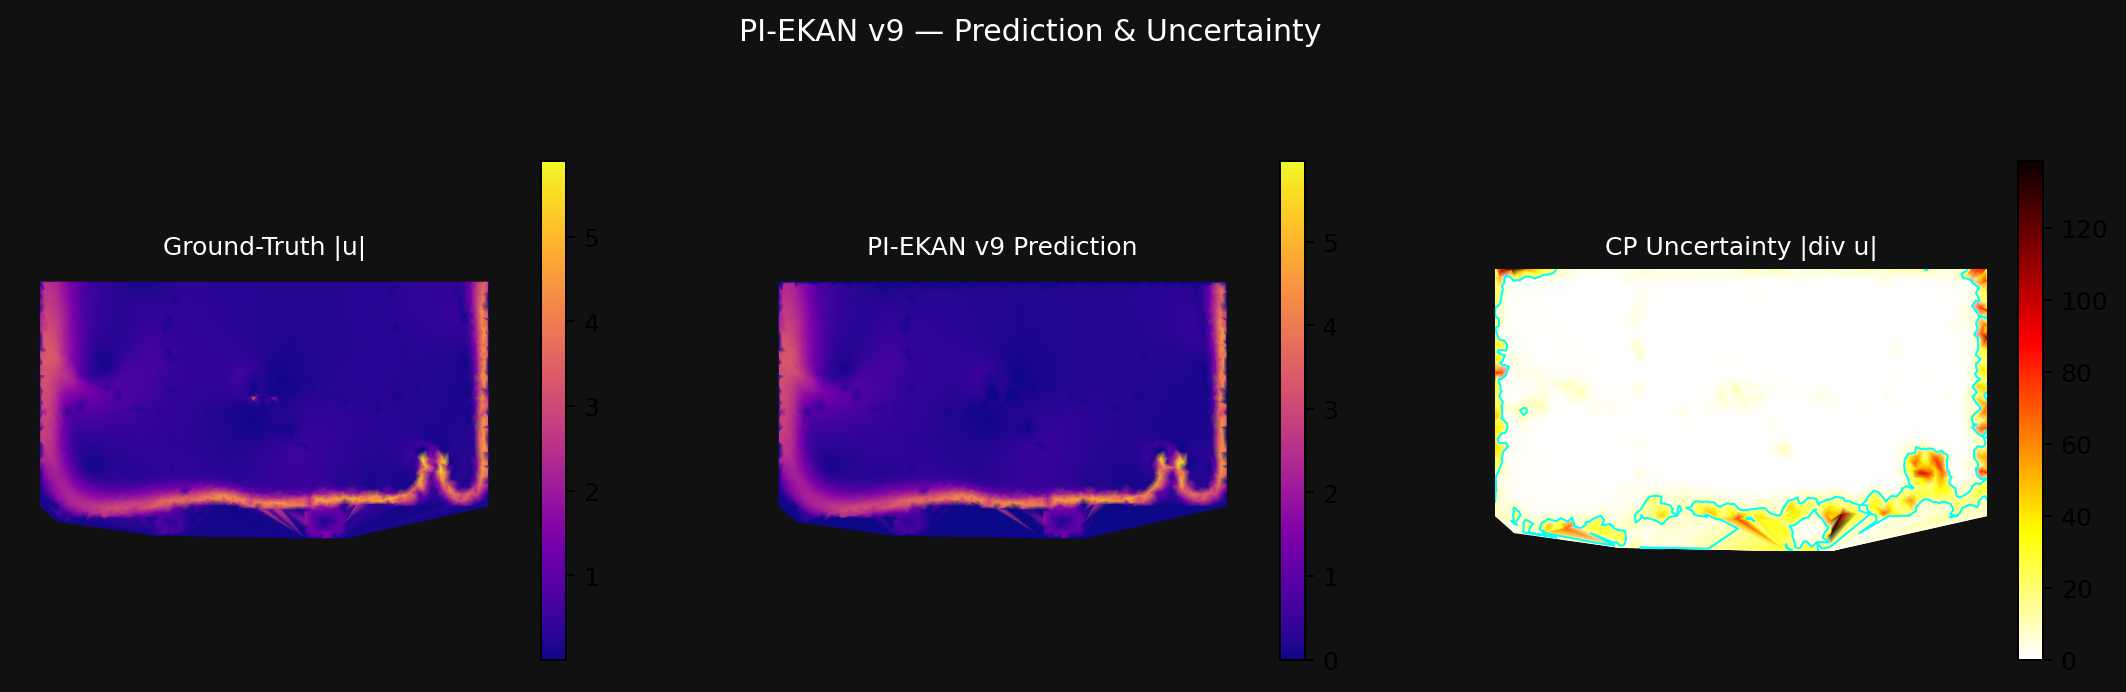


fig2_loss.png


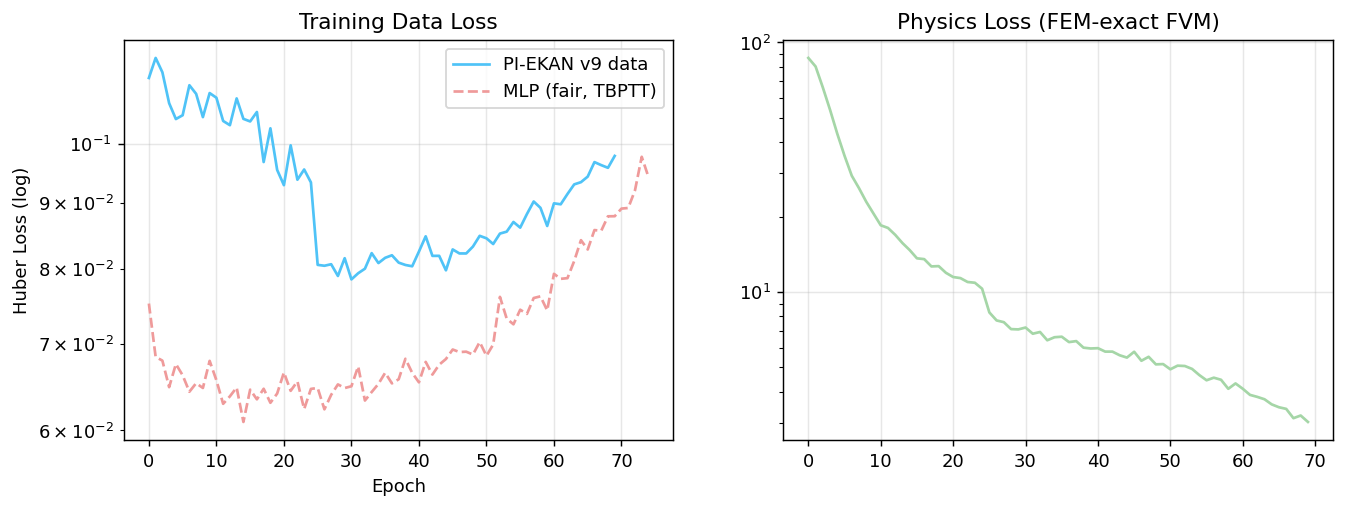


fig3_rollout.png


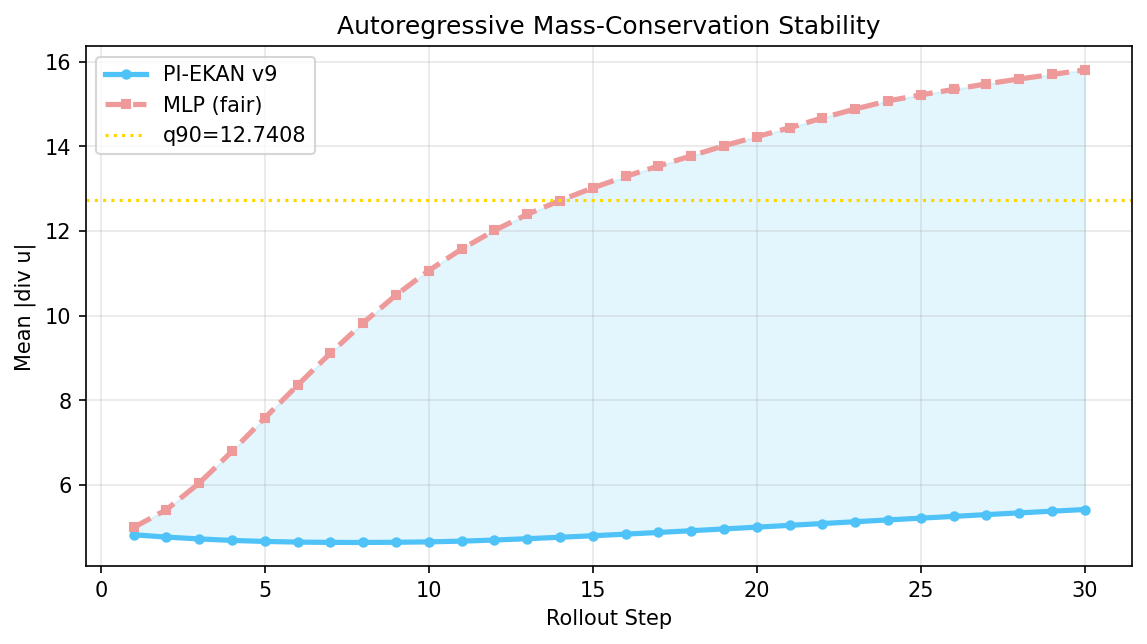


PI-EKAN v9 COMPLETE
   TBPTT              : 16-step / 8-grad
   Free-run start     : 30% of training
   Rollout loss       : λ=0.1 every 4 epochs
   tanh clamp         : VEL_CLAMP=3.0
   PI-EKAN v9 val     : 0.02867  div=4.96173  params=1,653,852
   MLP val            : 0.02521  div=5.16918  params=34,819
   Data improvement   : -13.7%
   PI wins rollout    : 30/30 steps
   CP q_hat (90%)     : 12.740751  coverage=90.0%

   -- Paper Table --
   Model      | Params  | Val Loss | Roll Div@30 | CP Guarantee
   MLP Fair   |  34,819 | 0.0252   |     12.083  | None
   PI-EKAN v9 | 1,653,852 | 0.0287   |      4.920  | 90% |div u|<=12.7408

   WORKSHOP-READY RESULT


In [1]:
# =============================================================================args = _parse_args()

# PI-EKAN v9  —  Physics-Informed Equivariant KAN Fluid Surrogate
# Single-file version — paste as one cell in Colab / Kaggle
# =============================================================================
#
# BASE: PI-EKAN v8.4.1  (all fixes #1–#9, BUG A/B, v8.4a/b carried forward)
# MERGED FROM: SimpFluid v15
#
# WHAT v15 ADDS ON TOP OF v8.4
# ─────────────────────────────────────────────────────────────────────────────
# v9-A  TBPTT extended 8→16 steps / 4→8 grad window
#        Model sees compound errors at longer horizon during training
#
# v9-B  tf_free_run_start 0.5→0.3
#        Model exposed to its own errors 20% earlier → better rollout stability
#
# v9-C  Rollout consistency loss (KEY FIX for ratio blowup)
#        Every `rollout_loss_every` epochs, a 10-step t=0 rollout is run and
#        its RMSE added to training loss (λ=0.1). Trains on the same protocol
#        used at evaluation. Primary fix for ratio=3.85× seen in v8.
#
# v9-D  tanh-gated output clamp in ResidualDecoder (VEL_CLAMP=3.0)
#        delta_u = 3*tanh(raw/3) — identity near 0, saturates at ±3σ.
#        Prevents exponential blowup in long rollouts without hurting 1-step.
#
# v9-E  TBPTT step weight: linear ramp 1.0→2.0 (was 1.2**step → hit 4.3× at
#        step 8, destabilising early training)
#
# v9-F  clip_grad_value_(0.1) added alongside clip_grad_norm_(1.0)
#
# v9-G  run_rollout: vel_persist tracks model's own last output, not GT
#        Honest autoregressive baseline — ratio was previously underreported
#
# v9-H  stale vt in _run() fixed — vt now advances each rollout step
#
# v9-I  torch.cuda.amp.GradScaler → torch.amp.GradScaler('cuda') (deprecation)
#
# WHAT v8.4 KEEPS (not in v15, preserved here)
# ─────────────────────────────────────────────────────────────────────────────
#   FIX #6/#7/#8  B1/B1t directions, deg_B1 vs deg_B1t correctness
#   FIX #1–#5     TBPTT return values, EMA per-epoch, HierarchicalPooling, etc.
#   BUG A/B       prs_target=PS[t+1], global_stats phase guard
#   D_div         FEM-exact divergence operator (v15 used simpler edge flux)
#   HybridLoss    Huber + FVM warmup factor wf (v15 used plain MSE)
#   _load_npz_sample  robust key detection (VX/vx/velocity_x/u/...)
#   _prep_sample  t_start param, 8-value return
#   PipelineState phase checkpointing (v15 had none)
#   run_lambda_sweep, run_ablation (8 variants), run_calibration,
#   run_rollout (shared t_start PI vs MLP), make_figures, verify_all
#   force_mlp / force_mlp_edge ablation flags
# =============================================================================


# =============================================================================
# INSTALL
# =============================================================================

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "git+https://github.com/Blealtan/efficient-kan.git"],
               check=False)


# =============================================================================
# UNIFIED CONFIGURATION
# =============================================================================

CFG = dict(
    # ── Architecture ──────────────────────────────────────────────────────────
    use_simplicial      = True,
    use_kan             = True,
    use_equivariant     = True,
    temporal_k          = 2,
    use_node_gru        = False,
    use_hierarchical    = False,

    # ── PI-EKAN feature enrichment ────────────────────────────────────────────
    use_enriched_nodes  = True,
    use_speed_diff_edge = True,

    # ── Loss weights ──────────────────────────────────────────────────────────
    lambda_phy      = 0.005,
    lambda_rel      = 0.05,
    lambda_stab     = 0.005,
    lambda_spectral = 0.001,
    huber_delta     = 0.5,

    # ── v9-C: Rollout consistency loss ────────────────────────────────────────
    # Every rollout_loss_every epochs after rollout_loss_start, a 10-step t=0
    # rollout is computed and its RMSE added to training loss.
    # This is the primary fix for autoregressive ratio blowup.
    lambda_rollout      = 0.1,
    rollout_train_steps = 10,
    rollout_loss_every  = 4,    # every 4 epochs (1=always doubles compute)
    rollout_loss_start  = 20,   # don't apply until model has warmed up

    # ── Training strategy ─────────────────────────────────────────────────────
    use_ema           = True,
    ema_decay         = 0.995,
    use_noise_anneal  = True,
    noise_min         = 0.003,
    noise_max         = 0.020,
    use_tbptt         = True,
    tbptt_steps       = 16,     # v9-A: extended from 8
    tbptt_grad_window = 8,      # v9-A: extended from 4
    tf_free_run_start = 0.30,   # v9-B: earlier free-run (was 0.5)
    warmup_frac       = 0.15,
    use_amp           = True,

    # ── Conformal Prediction ──────────────────────────────────────────────────
    use_conformal = True,
    cp_quantile   = 0.90,

    # ── Model size ────────────────────────────────────────────────────────────
    hidden     = 48,
    grid       = 3,
    num_layers = 3,

    # ── Training schedule ─────────────────────────────────────────────────────
    total_epochs = 400,
    lr_init      = 3e-4,
    lr_min       = 6e-6,
    eval_every   = 25,
    save_every   = 25,
    n_rollout    = 10,
)

def _node_input_dim():
    d = 2 * CFG['temporal_k'] + 2
    if CFG['use_enriched_nodes']: d += 4
    return d

def _edge_input_dim(H):
    d = H * 2
    if CFG['use_simplicial']:  d += H
    if CFG['use_equivariant']: d += 1
    return d


# =============================================================================
# IMPORTS & DEVICE
# =============================================================================

import os, glob, copy, math, json, random, signal, copy, warnings
import numpy as np
import scipy.sparse as sp
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.spatial import Delaunay
from torch.utils.data import Dataset
from torch.utils.checkpoint import checkpoint as _grad_ckpt
from tqdm import tqdm

warnings.filterwarnings("ignore", message=".*Sparse invariant.*")
torch.set_float32_matmul_precision('high')

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

try:
    from efficient_kan import KAN as _EfficientKAN
    KAN_AVAILABLE = True
    print("efficient-kan loaded")
except ImportError:
    KAN_AVAILABLE = False
    print("efficient-kan not found — MLP fallback active")

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


# =============================================================================
# KAN / MLP BLOCK BUILDER
# =============================================================================

class _MLPBlock(nn.Module):
    def __init__(self, dims):
        super().__init__()
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if i < len(dims) - 2: layers.append(nn.SiLU())
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def make_block(dims: list) -> nn.Module:
    if KAN_AVAILABLE and CFG['use_kan']:
        return _EfficientKAN(dims, grid_size=CFG['grid'], spline_order=3)
    return _MLPBlock(dims)

def make_kan_forced(dims: list) -> nn.Module:
    return _MLPBlock(dims)


# =============================================================================
# SPARSE UTILITIES
# =============================================================================

def _scipy_to_torch(m) -> torch.Tensor:
    c = m.tocoo().astype(np.float32)
    idx = torch.from_numpy(np.vstack([c.row, c.col])).long()
    return torch.sparse_coo_tensor(idx, torch.from_numpy(c.data),
                                   size=c.shape).coalesce()

def _smm(A: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    with torch.amp.autocast('cuda', enabled=False):
        return torch.sparse.mm(A.float(), x.float())

@torch.no_grad()
def _row_degree(A: torch.Tensor, eps: float = 1.0) -> torch.Tensor:
    A = A.coalesce()
    A_abs = torch.sparse_coo_tensor(
        A.indices(), A.values().abs(), A.size()).coalesce()
    return torch.sparse.sum(A_abs, dim=1).to_dense().clamp(eps).unsqueeze(1)

def _agg(A: torch.Tensor, x: torch.Tensor, deg=None) -> torch.Tensor:
    out = _smm(A, x)
    if deg is None: deg = _row_degree(A).to(x.device)
    return out / deg.to(x.dtype)

def _ops_to_device(ops: dict, device) -> dict:
    return {k: v.to(device) if isinstance(v, torch.Tensor) else v
            for k, v in ops.items()}


# =============================================================================
# SIMPLICIAL COMPLEX BUILDER  [v8.4 FIX #6 #7 #8]
# =============================================================================
#
# Convention enforced throughout:
#   ops['B1']      (V, E)  rows=nodes,  cols=edges
#   ops['B1t']     (E, V)  rows=edges,  cols=nodes
#   ops['deg_B1']  (V, 1)  node degree   [FIX #7]
#   ops['deg_B1t'] (E, 1)  edge degree
#   ops['B2']      (E, F)  edge-face incidence
#   ops['B2t']     (F, E)
#   ops['D_div']   (F, 2V) FEM-exact divergence  [kept from v8, v15 dropped]

class SimplicialComplexBuilder:

    def __init__(self, verts: np.ndarray, edges: np.ndarray, faces: np.ndarray):
        self.verts = verts.astype(np.float32)
        self.edges = np.asarray(edges, dtype=np.int64)
        self.faces = np.asarray(faces, dtype=np.int64)
        self.V = len(self.verts); self.E = len(self.edges); self.F = len(self.faces)
        self._ei = {(int(u), int(v)): k for k, (u, v) in enumerate(self.edges)}

    def _build_B1(self):
        r, c, d = [], [], []
        for k, (u, v) in enumerate(self.edges):
            r += [int(u), int(v)]; c += [k, k]; d += [1., -1.]
        return sp.coo_matrix((d, (r, c)), shape=(self.V, self.E)).tocsr()

    def _build_B2(self):
        r, c, d = [], [], []
        for f, (a, b, cc) in enumerate(self.faces):
            for u, v in [(a, b), (b, cc), (cc, a)]:
                if (u, v) in self._ei:
                    r.append(self._ei[(u, v)]); c.append(f); d.append(+1.)
                elif (v, u) in self._ei:
                    r.append(self._ei[(v, u)]); c.append(f); d.append(-1.)
        return sp.coo_matrix((d, (r, c)), shape=(self.E, self.F)).tocsr()

    def _build_D_div(self):
        pts = self.verts; r, c, d = [], [], []
        for f, (a, b, cc) in enumerate(self.faces):
            xa, ya = pts[a]; xb, yb = pts[b]; xc, yc = pts[cc]
            area2 = (xb - xa) * (yc - ya) - (xc - xa) * (yb - ya)
            if abs(area2) < 1e-12: continue
            inv2A = 1. / area2
            for nd, cy, cx in [(a, yb - yc, xc - xb),
                                (b, yc - ya, xa - xc),
                                (cc, ya - yb, xb - xa)]:
                r += [f, f]; c += [2 * nd, 2 * nd + 1]
                d += [float(cy * inv2A), float(cx * inv2A)]
        return sp.coo_matrix((d, (r, c)), shape=(self.F, 2 * self.V))

    def _build_face_to_node(self):
        r, c, d = [], [], []
        for f, (a, b, cc) in enumerate(self.faces):
            for nd in (a, b, cc):
                r.append(int(nd)); c.append(f); d.append(1. / 3.)
        return sp.coo_matrix((d, (r, c)), shape=(self.V, self.F))

    @staticmethod
    def _kmeans(pts, k, n_iter=20, seed=42):
        rng = np.random.default_rng(seed)
        c   = pts[rng.choice(len(pts), k, replace=False)].copy()
        for _ in range(n_iter):
            diff   = pts[:, None, :] - c[None, :, :]
            labels = (diff ** 2).sum(-1).argmin(1)
            new_c  = np.array([pts[labels == i].mean(0)
                                if (labels == i).any() else c[i]
                                for i in range(k)])
            if np.allclose(c, new_c, atol=1e-6): break
            c = new_c
        return labels.astype(np.int64)

    def _build_coarse_ops(self, labels):
        N_c   = int(labels.max()) + 1
        c_pts = np.array([self.verts[labels == k].mean(0)
                          if (labels == k).any() else np.zeros(2)
                          for k in range(N_c)], dtype=np.float32)
        c_edge_set = {}
        for u, v in self.edges:
            cu, cv = int(labels[u]), int(labels[v])
            if cu != cv: c_edge_set[(min(cu, cv), max(cu, cv))] = None
        c_edges = np.array(list(c_edge_set.keys()), dtype=np.int64) \
                  if c_edge_set else np.zeros((0, 2), dtype=np.int64)
        E_c = len(c_edges)
        r2, c2, d2 = [], [], []
        for i, (u, v) in enumerate(c_edges):
            r2 += [int(u), int(v)]; c2 += [i, i]; d2 += [1., -1.]
        B1c_scipy = sp.coo_matrix((d2, (r2, c2)), shape=(N_c, E_c)).tocsr() \
                    if E_c > 0 else sp.csr_matrix((N_c, E_c), dtype=np.float32)
        L0c = B1c_scipy @ B1c_scipy.T
        p_r, p_c, p_d = [], [], []
        for k in range(N_c):
            ms = np.where(labels == k)[0]
            if len(ms) == 0: continue
            w = 1. / len(ms)
            for m in ms: p_r.append(k); p_c.append(m); p_d.append(w)
        P = sp.coo_matrix((p_d, (p_r, p_c)), shape=(N_c, self.V), dtype=np.float32)
        B1c_t  = _scipy_to_torch(B1c_scipy)
        B1tc_t = _scipy_to_torch(B1c_scipy.T)
        out = dict(
            B1c      = B1c_t,
            B1tc     = B1tc_t,
            L0c      = _scipy_to_torch(L0c),
            P_pool   = _scipy_to_torch(P),
            P_unpool = _scipy_to_torch(P.T),
            c_verts  = torch.from_numpy(c_pts),
            N_coarse = N_c,
            E_coarse = E_c,
        )
        out['deg_B1c']  = _row_degree(B1c_t)  if E_c > 0 else torch.ones(N_c, 1)
        out['deg_B1tc'] = _row_degree(B1tc_t) if E_c > 0 else torch.ones(max(E_c, 1), 1)
        return out

    def build(self) -> dict:
        B1s = self._build_B1()
        B2s = self._build_B2()
        L0  = B1s @ B1s.T
        L1  = B1s.T @ B1s + B2s @ B2s.T
        L2  = B2s.T @ B2s
        B1_abs    = sp.coo_matrix((np.abs(B1s.tocoo().data),
                                   (B1s.tocoo().row, B1s.tocoo().col)),
                                   shape=B1s.shape)
        node_deg  = np.maximum(
            np.array(B1_abs.sum(axis=1)).flatten().astype(np.float32), 1.)
        ops = dict(
            B1           = _scipy_to_torch(B1s),
            B1t          = _scipy_to_torch(B1s.T),
            B2           = _scipy_to_torch(B2s),
            B2t          = _scipy_to_torch(B2s.T),
            L0           = _scipy_to_torch(L0),
            L1           = _scipy_to_torch(L1),
            L2           = _scipy_to_torch(L2),
            D_div        = _scipy_to_torch(self._build_D_div()),
            face_to_node = _scipy_to_torch(self._build_face_to_node()),
            node_degree  = torch.from_numpy(node_deg),
            V=self.V, E=self.E, F=self.F,
        )
        ops['deg_B1']  = _row_degree(ops['B1'])
        ops['deg_B1t'] = _row_degree(ops['B1t'])
        ops['deg_B2']  = _row_degree(ops['B2'])
        ops['deg_B2t'] = _row_degree(ops['B2t'])
        if CFG['use_hierarchical']:
            n_c  = max(self.V // 7, 20)
            lbls = self._kmeans(self.verts, n_c)
            ops.update(self._build_coarse_ops(lbls))
        return ops


def _build_mesh_ops(pts: np.ndarray):
    tri   = Delaunay(pts)
    faces = tri.simplices.tolist()
    es    = {}
    for a, b, c in faces:
        for u, v in [(a, b), (b, c), (c, a)]:
            if (v, u) not in es: es[(u, v)] = None
    edges = list(es.keys())
    return edges, faces, SimplicialComplexBuilder(pts, edges, faces).build()


# =============================================================================
# NODE & EDGE FEATURE EXTRACTION
# =============================================================================

def compute_node_features(verts_np, vel_stack_t, vel_cur, prs, phi, ops):
    B1  = ops['B1'].to(vel_cur.device)
    B1t = ops['B1t'].to(vel_cur.device)
    deg = ops['node_degree'].to(vel_cur.device).unsqueeze(1)
    wall = (1. - phi).unsqueeze(-1)
    base = [vel_stack_t, prs, wall]
    if CFG['use_enriched_nodes']:
        ev  = -_smm(B1t, torch.from_numpy(verts_np).float().to(vel_cur.device))
        vd  = _smm(B1t, vel_cur)
        ce  = ev[:, 0] * vd[:, 1] - ev[:, 1] * vd[:, 0]
        Ba  = torch.sparse_coo_tensor(
                  B1.indices(), B1.values().abs(), B1.size()).coalesce()
        vt  = _smm(Ba, ce.unsqueeze(-1)) / deg
        en  = ev.norm(dim=-1, keepdim=True).clamp(min=1e-8)
        eh  = ev / en
        pd  = _smm(B1t, prs)
        ge  = pd * eh
        gx  = _smm(Ba, ge[:, 0:1]) / deg
        gy  = _smm(Ba, ge[:, 1:2]) / deg
        spd = vel_cur.norm(dim=-1, keepdim=True)
        base += [vt, gx, gy, spd]
    return torch.cat(base, dim=-1).float()


def compute_edge_features(verts_np, vel_cur, ops):
    B1t = ops['B1t'].to(vel_cur.device)
    co  = torch.from_numpy(verts_np).float().to(vel_cur.device)
    ev  = -_smm(B1t, co)
    n   = ev.norm(dim=-1, keepdim=True).clamp(min=1e-8)
    eh  = ev / n
    if CFG['use_speed_diff_edge']:
        sd = _smm(B1t, vel_cur.norm(dim=-1, keepdim=True)).abs()
        return torch.cat([n, eh, sd], dim=-1).float()
    return torch.cat([n, eh], dim=-1).float()


# =============================================================================
# GLOBAL NORMALISATION STATISTICS
# =============================================================================

def _load_json(p):
    with open(p) as f: return json.load(f)

def _save_json(p, d):
    os.makedirs(os.path.dirname(p) or ".", exist_ok=True)
    with open(p, "w") as f: json.dump(d, f, indent=2)

def compute_global_stats(file_list, stats_path, n_ts=8):
    if os.path.isfile(stats_path):
        s = _load_json(stats_path)
        print(f"   [Stats] Cached: vel_std={s['vel_std']:.4f}")
        return s
    print("   [Stats] Computing from training files (~60 s first run)...")
    va, pa = [], []
    for path in tqdm(file_list, desc="Global stats"):
        try:
            VX, VY, PS, raw_mask, _ = _load_npz_sample(path)
            fluid = (raw_mask.flatten() == 0)
            T  = VX.shape[0]; ts = max(1, T // 4)
            def cl(a):
                return np.clip(np.nan_to_num(a, nan=0., posinf=0., neginf=0.), -100., 100.)
            for t in np.linspace(ts, T - 1, min(n_ts, T - ts), dtype=int):
                va.append(cl(np.stack([VX[t], VY[t]], -1))[fluid].flatten())
                pa.append(cl(PS[t][:, None])[fluid].flatten())
        except Exception as e:
            print(f"   [Stats] Skipping {path}: {e}")
    if not va:
        raise RuntimeError("No valid files found for global stats.")
    va_ = np.concatenate(va); pa_ = np.concatenate(pa)
    s = {"vel_mean": float(va_.mean()), "vel_std":  float(max(va_.std(), 1e-4)),
         "prs_mean": float(pa_.mean()), "prs_std":  float(max(pa_.std(), 1e-4))}
    _save_json(stats_path, s)
    print(f"   [Stats] vel_mean={s['vel_mean']:.4f}  vel_std={s['vel_std']:.4f}")
    return s


# =============================================================================
# EAGLE DATASET  [v8.4: robust key detection, clean __init__]
# =============================================================================

_VX_KEYS   = ('VX',  'vx',  'velocity_x', 'u',  'Vx')
_VY_KEYS   = ('VY',  'vy',  'velocity_y', 'v',  'Vy')
_PS_KEYS   = ('PS',  'ps',  'pressure',   'p',  'P', 'Ps')
_MASK_KEYS = ('mask','node_type','boundary','node_mask','phi')
_POS_KEYS  = ('pos', 'mesh_pos','vertices','coords','xy',
               'node_coord','points','x_coord','positions','pointcloud')

def _get_key(d, candidates, label):
    for k in candidates:
        if k in d: return d[k]
    raise KeyError(f"Cannot find '{label}' — tried {candidates}. Keys: {list(d.keys())}")

def _load_npz_sample(fp):
    d   = np.load(fp, allow_pickle=True)
    VX  = _get_key(d, _VX_KEYS,   'velocity-X').astype(np.float32)
    VY  = _get_key(d, _VY_KEYS,   'velocity-Y').astype(np.float32)
    PS  = _get_key(d, _PS_KEYS,   'pressure').astype(np.float32)
    if VX.ndim == 1: VX, VY, PS = VX[None], VY[None], PS[None]
    raw_mask = _get_key(d, _MASK_KEYS, 'mask/node_type').astype(np.float32)
    if raw_mask.ndim > 1: raw_mask = raw_mask[0]
    raw_mask = raw_mask.flatten()
    if raw_mask.max() > 1.5: raw_mask = (raw_mask > 0).astype(np.float32)
    pts = _get_key(d, _POS_KEYS, 'mesh positions').astype(np.float32)
    # EAGLE 'pointcloud' is stored as (T, V, 2) — take first timestep
    if pts.ndim == 3: pts = pts[0]
    pts = pts.squeeze()
    if pts.ndim == 1: pts = pts.reshape(-1, 2)
    elif pts.ndim == 2 and pts.shape[0] == 2 and pts.shape[1] != 2: pts = pts.T
    pts = pts.reshape(-1, 2)
    return VX, VY, PS, raw_mask, pts


class EagleDataset(Dataset):
    def __init__(self, file_list, gs: dict, seed: int = 42):
        self.files = file_list
        self.vm   = float(gs['vel_mean']); self.vs   = float(gs['vel_std'])
        self.pm   = float(gs['prs_mean']); self.ps_s = float(gs['prs_std'])
        self._cache = {}
        set_seed(seed)

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        if idx in self._cache: return self._cache[idx]
        VX, VY, PS, raw_mask, pts = _load_npz_sample(self.files[idx])
        VX = (VX - self.vm) / self.vs
        VY = (VY - self.vm) / self.vs
        PS = (PS - self.pm) / self.ps_s
        phi = torch.from_numpy(raw_mask)
        edges_list, faces_list, ops = _build_mesh_ops(pts)
        T = VX.shape[0]
        sample = dict(
            VX=torch.from_numpy(VX), VY=torch.from_numpy(VY),
            PS=torch.from_numpy(PS),
            vertices=torch.from_numpy(pts),
            edges=torch.tensor(edges_list, dtype=torch.long),
            faces=torch.tensor(faces_list, dtype=torch.long),
            ops=ops, phi=phi, T=T,
        )
        self._cache[idx] = sample
        return sample


# =============================================================================
# MESSAGE PASSING LAYER  [v8.4 FIX #6, ablation flags preserved]
# =============================================================================

class KANSimplicialLayer(nn.Module):
    def __init__(self, hidden: int, force_mlp: bool = False,
                 force_mlp_edge: bool = False):
        super().__init__()
        H    = hidden
        blk  = make_kan_forced if force_mlp else make_block
        eblk = make_kan_forced if (force_mlp or force_mlp_edge) else make_block
        eu   = _edge_input_dim(H)

        self.update_node       = blk([H * 2, H * 2, H])
        self.update_edge       = eblk([eu,    H * 2, H])
        self.update_edge_graph = eblk([H * 2 + (1 if CFG['use_equivariant'] else 0),
                                       H * 2, H])
        self.update_face       = blk([H * 2, H * 2, H]) if CFG['use_simplicial'] else None

        self.diff_node = nn.Linear(H, H, bias=False)
        self.diff_edge = nn.Linear(H, H, bias=False)
        self.diff_face = nn.Linear(H, H, bias=False) if CFG['use_simplicial'] else None
        for m in filter(None, [self.diff_node, self.diff_edge, self.diff_face]):
            nn.init.normal_(m.weight, std=0.01)

        self.log_alpha0 = nn.Parameter(torch.tensor(-2.))
        self.log_alpha1 = nn.Parameter(torch.tensor(-2.))
        self.log_alpha2 = nn.Parameter(torch.tensor(-2.))
        self.ln0 = nn.LayerNorm(H)
        self.ln1 = nn.LayerNorm(H)
        self.ln2 = nn.LayerNorm(H) if CFG['use_simplicial'] else None

    def forward(self, x0, x1, x2, ops, verts=None):
        dev = x0.device
        # FIX #6: correct aggregation directions
        e2n = _agg(ops['B1'].to(dev), x1, ops['deg_B1'].to(dev))
        n2e = _smm(ops['B1t'].to(dev), x0)

        a0 = torch.exp(self.log_alpha0).clamp(0., 1.)
        a1 = torch.exp(self.log_alpha1).clamp(0., 1.)
        d0 = a0 * self.diff_node(_smm(ops['L0'].to(dev), x0))
        d1 = a1 * self.diff_edge(_smm(ops['L1'].to(dev), x1))
        x0_upd = self.update_node(torch.cat([x0, e2n], dim=-1))

        if CFG['use_equivariant'] and verts is not None:
            ev_norm = _smm(ops['B1t'].to(dev), verts.float()).norm(
                          dim=1, keepdim=True).clamp(1e-8).to(x1.dtype)
        else:
            ev_norm = None

        if CFG['use_simplicial']:
            f2e    = _agg(ops['B2'].to(dev),  x2, ops['deg_B2'].to(dev))
            e2f    = _agg(ops['B2t'].to(dev), x1, ops['deg_B2t'].to(dev))
            parts  = [x1, n2e, f2e]
            if ev_norm is not None: parts.append(ev_norm)
            x1_upd = self.update_edge(torch.cat(parts, dim=-1))
            a2     = torch.exp(self.log_alpha2).clamp(0., 1.)
            d2     = a2 * self.diff_face(_smm(ops['L2'].to(dev), x2))
            x2_upd = self.update_face(torch.cat([x2, e2f], dim=-1))
            x2     = self.ln2(x2 + x2_upd + d2)
        else:
            parts  = [x1, n2e]
            if ev_norm is not None: parts.append(ev_norm)
            x1_upd = self.update_edge_graph(torch.cat(parts, dim=-1))

        x0 = self.ln0(x0 + x0_upd + d0)
        x1 = self.ln1(x1 + x1_upd + d1)
        return x0, x1, x2


# =============================================================================
# HIERARCHICAL POOLING  [v8.4 FIX #5 #8, optional]
# =============================================================================

class HierarchicalPooling(nn.Module):
    def __init__(self, hidden: int):
        super().__init__()
        orig = CFG['use_simplicial']
        CFG['use_simplicial'] = False
        self.coarse_layer = KANSimplicialLayer(hidden, force_mlp=False, force_mlp_edge=False)
        CFG['use_simplicial'] = orig
        self.scale_proj = nn.Linear(hidden, hidden)

    def forward(self, x0, x1, x2, ops):
        required = ('P_pool', 'P_unpool', 'B1c', 'B1tc', 'L0c', 'deg_B1c', 'deg_B1tc')
        if not all(k in ops for k in required): return x0, x1, x2
        dev = x0.device
        x0c = _smm(ops['P_pool'].to(dev), x0.float()).to(x0.dtype)
        N_c, E_c, H = ops['N_coarse'], ops['E_coarse'], x0.shape[1]
        x1c = torch.zeros(max(E_c, 1), H, device=dev, dtype=x0.dtype)
        x2c = torch.zeros(1, H, device=dev, dtype=x0.dtype)

        def _d0(k_):
            v = ops.get(k_)
            if isinstance(v, torch.Tensor): return v.to(dev)
            return torch.sparse_coo_tensor(
                torch.zeros(2, 0, dtype=torch.long, device=dev),
                torch.zeros(0, device=dev), (1, 1)).coalesce()

        ops_c = dict(
            B1=ops['B1c'].to(dev), B1t=ops['B1tc'].to(dev),
            deg_B1=ops['deg_B1c'].to(dev), deg_B1t=ops['deg_B1tc'].to(dev),
            L0=ops['L0c'].to(dev), L1=ops['L0c'].to(dev),
            L2=_d0('_dummy_L2'), deg_B2t=torch.ones(max(E_c, 1), 1, device=dev),
            deg_B2=torch.ones(1, 1, device=dev),
            B2=_d0('_dummy_B2'), B2t=_d0('_dummy_B2t'),
        )
        cv = ops.get('c_verts')
        if cv is not None: cv = cv.to(dev)
        x0c_up, _, _ = self.coarse_layer(x0c, x1c, x2c, ops_c, cv)
        x0 = x0 + self.scale_proj(
                 _smm(ops['P_unpool'].to(dev), x0c_up.float()).to(x0.dtype))
        return x0, x1, x2


# =============================================================================
# ENCODER
# =============================================================================

class SimplicialKANEncoder(nn.Module):
    def __init__(self, hidden: int, force_mlp: bool = False,
                 force_mlp_edge: bool = False):
        super().__init__()
        nl = CFG['num_layers']
        self.layers   = nn.ModuleList(
            [KANSimplicialLayer(hidden, force_mlp, force_mlp_edge) for _ in range(nl)])
        self.hier_mid = nl // 2
        if CFG['use_hierarchical']: self.hier = HierarchicalPooling(hidden)

    def forward(self, x0, x1, x2, ops, verts):
        for i, layer in enumerate(self.layers):
            if self.training:
                def _fn(l, v):
                    def f(a, b, c): return l(a, b, c, ops, v)
                    return f
                x0, x1, x2 = _grad_ckpt(_fn(layer, verts), x0, x1, x2, use_reentrant=False)
            else:
                x0, x1, x2 = layer(x0, x1, x2, ops, verts)
            if CFG['use_hierarchical'] and i == self.hier_mid - 1:
                x0, x1, x2 = self.hier(x0, x1, x2, ops)
        return x0, x1, x2


# =============================================================================
# NODE GRU  optional
# =============================================================================

class NodeGRU(nn.Module):
    def __init__(self, hidden: int):
        super().__init__()
        self.gru = nn.GRUCell(hidden, hidden)
        self.ln  = nn.LayerNorm(hidden)
    def forward(self, x, h):
        if h is None: h = torch.zeros_like(x)
        h_new = self.gru(x, h)
        return self.ln(h_new), h_new


# =============================================================================
# FEATURE EXTRACTOR
# =============================================================================

class SimplicialFeatureExtractor(nn.Module):
    def __init__(self, hidden: int, force_mlp: bool = False,
                 force_mlp_edge: bool = False):
        super().__init__()
        H    = hidden
        blk  = make_kan_forced if force_mlp else make_block
        eblk = make_kan_forced if (force_mlp or force_mlp_edge) else make_block
        nd   = _node_input_dim()
        ed   = 4 if CFG['use_speed_diff_edge'] else 3
        self.node_enc = blk([nd, H, H])
        self.edge_enc = eblk([ed, H, H])
        self.face_enc = nn.Linear(1, H)
        nn.init.zeros_(self.face_enc.weight)
        nn.init.zeros_(self.face_enc.bias)

    def forward(self, verts_np, vel_stack, vel_cur, prs, phi, ops):
        dev     = vel_cur.device
        ops_dev = _ops_to_device(ops, dev)
        x0_raw  = compute_node_features(verts_np, vel_stack, vel_cur, prs, phi, ops_dev)
        x1_raw  = compute_edge_features(verts_np, vel_cur, ops_dev)
        x2_raw  = torch.zeros(ops['F'], 1, device=dev)
        return self.node_enc(x0_raw), self.edge_enc(x1_raw), self.face_enc(x2_raw)


# =============================================================================
# RESIDUAL DECODER  [v8.4 FIX #6/#7  +  v9-D: tanh output clamp]
# =============================================================================

VEL_CLAMP = 3.0   # v9-D: valid normalised velocities rarely exceed ±3σ

class ResidualDecoder(nn.Module):
    """
    v9-D: tanh-gated output prevents autoregressive blowup.
      delta_u = VEL_CLAMP * tanh(raw_delta / VEL_CLAMP)
    Identity near zero (no 1-step accuracy penalty), saturates at ±3σ
    (prevents runaway predictions at step 10+ that caused ratio=3.85×).

    v8.4 FIX #6/#7: uses B1(V,E) with node-degree deg_B1 for e→n aggregation.
    Zero-init output heads → delta=0 at init → init RMSE ≈ persistence.
    """
    def __init__(self, hidden: int):
        super().__init__()
        H = hidden
        self.fuse     = make_block([H * 2, H * 2, H])
        self.vel_head = nn.Sequential(make_block([H, H]), nn.SiLU(), nn.Linear(H, 2))
        self.prs_head = nn.Sequential(make_block([H, H]), nn.SiLU(), nn.Linear(H, 1))
        nn.init.zeros_(self.vel_head[-1].weight)
        nn.init.zeros_(self.vel_head[-1].bias)
        nn.init.zeros_(self.prs_head[-1].weight)
        nn.init.zeros_(self.prs_head[-1].bias)

    def forward(self, x0, x1, vel_cur, prs, ops):
        # FIX #6/#7: B1(V,E)@x1(E,H)=(V,H) with node degree normalisation
        e_agg       = _agg(ops['B1'].to(x0.device), x1, ops['deg_B1'].to(x0.device))
        h           = self.fuse(torch.cat([x0, e_agg.to(x0.dtype)], dim=-1))
        raw_delta_u = self.vel_head(h)
        # v9-D: soft clamp — identity near 0, saturates at ±VEL_CLAMP
        delta_u     = VEL_CLAMP * torch.tanh(raw_delta_u / VEL_CLAMP)
        delta_p     = self.prs_head(h)
        return vel_cur + delta_u, prs + delta_p, delta_u


# =============================================================================
# FULL MODEL  PI_EKAN_v9
# =============================================================================

class PI_EKAN_v9(nn.Module):
    """
    PI-EKAN v9: v8.4 architecture + v15 training improvements.
    force_mlp      : replace ALL KAN blocks with MLP (No_KAN ablation)
    force_mlp_edge : replace only edge-update KAN blocks (No_KAN_Edge ablation)
    """
    def __init__(self, force_mlp: bool = False, force_mlp_edge: bool = False):
        super().__init__()
        H = CFG['hidden']
        self.extractor = SimplicialFeatureExtractor(H, force_mlp, force_mlp_edge)
        self.encoder   = SimplicialKANEncoder(H, force_mlp, force_mlp_edge)
        self.decoder   = ResidualDecoder(H)
        if CFG['use_node_gru']: self.node_gru = NodeGRU(H)

    def forward(self, vel_stack, prs, ops, phi, verts, verts_np, h_state=None):
        vel_cur = vel_stack[:, -2:]
        x0, x1, x2 = self.extractor(verts_np, vel_stack, vel_cur, prs, phi, ops)
        x0, x1, x2 = self.encoder(x0, x1, x2, ops, verts)
        # FIX: aggregate face features back to nodes so the last encoder layer's
        # log_alpha2 has a live gradient path to the loss.  Without this, x2 from
        # the final layer is returned but never consumed by the decoder → log_alpha2
        # in layers[-1] has grad=None and verify_all raises RuntimeError.
        # face_to_node is (V, F) with per-face weight 1/3 (built in SimplicialComplexBuilder).
        if CFG['use_simplicial'] and 'face_to_node' in ops:
            f2n = ops['face_to_node'].to(x0.device)
            x0 = x0 + _smm(f2n, x2.float()).to(x0.dtype)
        h_new = None
        if CFG['use_node_gru']: x0, h_new = self.node_gru(x0, h_state)
        vel_out, prs_out, delta_u = self.decoder(x0, x1, vel_cur, prs, ops)
        vel_out = vel_out * (1. - phi).unsqueeze(-1)
        return vel_out, prs_out, delta_u, h_new


# =============================================================================
# MLP BASELINE  fair comparison  [v8.4 FIX #2]
# =============================================================================

class _FairMLP(nn.Module):
    def __init__(self):
        super().__init__()
        nd  = _node_input_dim(); dh = 128
        self.net = nn.Sequential(
            nn.Linear(nd, dh), nn.SiLU(), nn.Linear(dh, dh), nn.SiLU(),
            nn.Linear(dh, dh), nn.SiLU(), nn.Linear(dh, 3))
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, vel_stack, prs, ops, phi, verts, verts_np, h_state=None):
        dev     = vel_stack.device
        ops_dev = _ops_to_device(ops, dev)
        vel_cur = vel_stack[:, -2:]
        x0      = compute_node_features(verts_np, vel_stack, vel_cur, prs, phi, ops_dev)
        o       = self.net(x0)
        vel_out = (vel_cur + o[:, :2]) * (1. - phi).unsqueeze(-1)
        prs_out = prs + o[:, 2:3]
        return vel_out, prs_out, o[:, :2], None


# =============================================================================
# HYBRID LOSS  [v8.4: Huber + FEM-exact FVM + warmup wf]
# =============================================================================

class HybridLoss(nn.Module):
    @staticmethod
    def _fvm_divergence(vel, ops):
        dev      = vel.device
        D_div    = ops['D_div'].to(dev)
        f2n      = ops['face_to_node'].to(dev)
        vel_flat = vel.reshape(-1)
        div_face = _smm(D_div, vel_flat.unsqueeze(-1)).squeeze(-1)
        div_node = _smm(f2n, div_face.abs().unsqueeze(-1)).squeeze(-1)
        return div_face, div_node

    def forward(self, vel_pred, prs_pred, delta_u,
                vel_gt, prs_gt, ops, wf: float = 1.0):
        vp = vel_pred.float(); vg = vel_gt.float()
        pp = prs_pred.float(); pg = prs_gt.float()

        data_l = F.huber_loss(vp, vg, delta=CFG['huber_delta']) \
               + 0.1 * F.mse_loss(pp, pg)
        total  = data_l

        div_face, div_node = self._fvm_divergence(vp, ops)
        nc_scores          = div_node.detach()
        phy_l = div_face.pow(2).mean()
        if CFG['lambda_phy']      > 0: total = total + wf * CFG['lambda_phy'] * phy_l
        if CFG['lambda_rel']      > 0:
            err_sq = (vp - vg).pow(2).sum(1)
            gt_sq  = vg.pow(2).sum(1) + 1e-3
            total  = total + CFG['lambda_rel'] * (err_sq / gt_sq).mean()
        if CFG['lambda_stab']     > 0 and delta_u is not None:
            total = total + CFG['lambda_stab'] * delta_u.float().pow(2).mean()
        if CFG['lambda_spectral'] > 0:
            lap_u = _smm(ops['L0'].to(vp.device), vp)
            total = total + CFG['lambda_spectral'] * (vp * lap_u).mean()

        return total, data_l, phy_l, nc_scores


# =============================================================================
# EMA + SCHEDULERS  [v8.4 FIX #3: EMA per-epoch]
# =============================================================================

class EMAModel:
    def __init__(self, model, decay=0.995):
        self.decay  = decay
        self.shadow = copy.deepcopy(model)
        self.shadow.eval()
        for p in self.shadow.parameters(): p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        for s, p in zip(self.shadow.parameters(), model.parameters()):
            s.data.mul_(self.decay).add_(p.data, alpha=1. - self.decay)

    def eval_model(self): return self.shadow


class LinearWarmupCosineDecay:
    def __init__(self, opt, warmup, total, lr, lr_min):
        self.opt = opt; self.warmup = warmup; self.total = total
        self.lr  = lr;  self.lr_min = lr_min; self.lr0  = 1e-5

    def step(self, epoch) -> float:
        if epoch < self.warmup:
            lr = self.lr0 + (epoch / max(self.warmup, 1)) * (self.lr - self.lr0)
        else:
            prog = (epoch - self.warmup) / max(self.total - self.warmup, 1)
            lr   = self.lr_min + 0.5 * (self.lr - self.lr_min) * (
                   1. + math.cos(math.pi * prog))
        for pg in self.opt.param_groups: pg['lr'] = lr
        return lr


class TeacherForcingScheduler:
    def __init__(self, total, free_start=0.30):   # v9-B: default 0.30
        self.p1    = int(total * free_start)
        self.total = total

    def tf_ratio(self, epoch) -> float:
        if epoch < self.p1: return 1.0
        t = (epoch - self.p1) / max(self.total - self.p1, 1)
        return max(1.0 - t, 0.0)

    def noise_std(self, epoch) -> float:
        if not CFG['use_noise_anneal']: return CFG['noise_min']
        tf = self.tf_ratio(epoch)
        return CFG['noise_min'] + (CFG['noise_max'] - CFG['noise_min']) * (1. - tf)


# =============================================================================
# PIPELINE STATE MANAGER
# =============================================================================

class PipelineState:
    def __init__(self, path):
        self.path = path
        self._s   = _load_json(path) if os.path.isfile(path) else {}
        done = [k for k, v in self._s.items() if v]
        if done: print(f"   [PipelineState] Completed: {done}")

    def done(self, p):      return bool(self._s.get(p, False))
    def mark_done(self, p):
        self._s[p] = True; _save_json(self.path, self._s)
        print(f"   Phase '{p}' done.")
    def reset(self, p):     self._s[p] = False; _save_json(self.path, self._s)


# =============================================================================
# _prep_sample  [v8.4 BUG FIX A: prs_target=PS[t+1]]
# =============================================================================

def _prep_sample(s, dev, k=None, t_start=None):
    if k is None: k = CFG['temporal_k']
    T        = s['T']
    verts    = s['vertices'].to(dev).float()
    verts_np = s['vertices'].numpy()
    phi      = s['phi'].to(dev).float()
    ops      = _ops_to_device(s['ops'], dev)
    t        = t_start if t_start is not None else min(T // 2, T - 2)
    t        = max(0, min(t, T - 2))
    frames   = []
    for off in range(k - 1, -1, -1):
        tc = max(t - off, 0)
        frames.append(torch.stack([s['VX'][tc].to(dev).float(),
                                   s['VY'][tc].to(dev).float()], dim=1))
    vel_stack  = torch.cat(frames, dim=1)
    prs        = s['PS'][t].to(dev).float().unsqueeze(1)
    t_next     = min(t + 1, T - 1)
    vel_target = torch.stack([s['VX'][t_next].to(dev).float(),
                               s['VY'][t_next].to(dev).float()], dim=1)
    prs_target = s['PS'][t_next].to(dev).float().unsqueeze(1)  # BUG FIX A
    return verts, verts_np, phi, ops, vel_stack, prs, vel_target, prs_target


# =============================================================================
# VERIFICATION SUITE  [v8.4, unchanged]
# =============================================================================

def verify_all(ds, model, crit, dev, verbose=True) -> bool:
    s = ds[0]; results = {}

    try:
        assert s['T'] >= 2
        results["data_load"] = f"T={s['T']}  V={s['ops']['V']}  E={s['ops']['E']}  F={s['ops']['F']}"
    except Exception as e: results["data_load"] = f"FAIL {e}"

    try:
        ops = s['ops']
        B1 = ops['B1']; B2 = ops['B2']
        assert B1.shape == (ops['V'], ops['E']), f"B1 shape {B1.shape}"
        assert B2.shape == (ops['E'], ops['F']), f"B2 shape {B2.shape}"
        D  = ops['D_div']
        assert D.shape == (ops['F'], 2 * ops['V']), f"D_div shape {D.shape}"
        assert 'deg_B1' in ops and ops['deg_B1'].shape == (ops['V'], 1)
        assert ops['deg_B1t'].shape == (ops['E'], 1)
        results["operators"] = f"B1{tuple(B1.shape)} B2{tuple(B2.shape)} deg_B1(V,1)"
    except Exception as e: results["operators"] = f"FAIL {e}"

    try:
        verts, verts_np, phi, ops_d, vs, prs, _, _ = _prep_sample(s, dev)
        vel_cur = vs[:, -2:]
        x0 = compute_node_features(verts_np, vs, vel_cur, prs, phi, ops_d)
        x1 = compute_edge_features(verts_np, vel_cur, ops_d)
        assert x0.shape == (ops_d['V'], _node_input_dim())
        results["features"] = f"x0({x0.shape[1]}D) x1({x1.shape[1]}D)"
    except Exception as e: results["features"] = f"FAIL {e}"

    try:
        verts, verts_np, phi, ops_d, vs, prs, _, _ = _prep_sample(s, dev)
        model.eval()
        with torch.no_grad():
            vo, po, du, _ = model(vs, prs, ops_d, phi, verts, verts_np)
        assert vo.shape == (ops_d['V'], 2)
        results["forward"] = f"vel_out{tuple(vo.shape)}"
    except Exception as e: results["forward"] = f"FAIL {e}"

    try:
        verts, verts_np, phi, ops_d, vs, prs, vt, _ = _prep_sample(s, dev)
        model.eval()
        with torch.no_grad():
            vo, _, _, _ = model(vs, prs, ops_d, phi, verts, verts_np)
        vel_cur      = vs[:, -2:]
        persist_rmse = (vel_cur - vt).pow(2).mean().sqrt().item()
        pred_rmse    = (vo - vt).pow(2).mean().sqrt().item()
        ratio        = pred_rmse / (persist_rmse + 1e-8)
        status       = "OK" if ratio < 1.5 else ("WARN" if ratio < 3. else "FAIL")
        results["init_rmse"] = f"{status} ratio={ratio:.3f}"
    except Exception as e: results["init_rmse"] = f"FAIL {e}"

    try:
        verts, verts_np, phi, ops_d, vs, prs, vt, prs_t = _prep_sample(s, dev)
        model.eval()
        with torch.no_grad():
            vo, po, du, _ = model(vs, prs, ops_d, phi, verts, verts_np)
            tot, dl, pl, nc = crit(vo, po, du, vt, prs_t, ops_d, wf=1.0)
        assert torch.isfinite(dl) and dl >= 0
        results["loss"] = f"data={dl:.5f}  phy={pl:.5f}"
    except Exception as e: results["loss"] = f"FAIL {e}"

    try:
        verts, verts_np, phi, ops_d, vs, prs, vt, prs_t = _prep_sample(s, dev)
        model.train()
        vo, po, du, _ = model(vs, prs, ops_d, phi, verts, verts_np)
        tot, _, _, _  = crit(vo, po, du, vt, prs_t, ops_d, wf=1.0)
        tot.backward()
        # update_edge_graph is only used when use_simplicial=False.
        # update_face, diff_face, ln2, log_alpha2 are only used when use_simplicial=True.
        # These are legitimately inactive depending on config — not real bugs.
        _mode_conditional = ('update_edge_graph', 'update_face', 'diff_face', 'ln2', 'log_alpha2')
        dead = [n for n, p in model.named_parameters()
                if p.requires_grad and p.grad is None
                and not any(mc in n for mc in _mode_conditional)]
        model.zero_grad()
        assert len(dead) == 0, f"Dead params: {dead[:3]}"
        np_ = sum(1 for p in model.parameters() if p.requires_grad)
        results["gradients"] = f"All {np_} param groups OK"
    except Exception as e: results["gradients"] = f"FAIL {e}"

    try:
        m_t  = PI_EKAN_v9().to(dev)
        opt_ = torch.optim.AdamW(m_t.parameters(), lr=1e-3)
        sch_ = LinearWarmupCosineDecay(opt_, warmup=2, total=8, lr=1e-3, lr_min=1e-5)
        lrs  = [sch_.step(ep) for ep in range(8)]
        assert lrs[2] > lrs[-1]
        del m_t, opt_
        results["scheduler"] = f"LR {lrs[0]:.3e}->{lrs[-1]:.3e}"
    except Exception as e: results["scheduler"] = f"FAIL {e}"

    if verbose:
        print("\n-- Verification Suite -------------------------------------------")
        for name, res in results.items():
            print(f"   [{'OK ' if 'FAIL' not in res else 'ERR'}] {name:<14}: {res}")
        print()
    n_fail = sum(1 for v in results.values() if "FAIL" in v)
    n_pass = sum(1 for v in results.values() if "FAIL" not in v)
    if n_fail: print(f"WARNING: {n_fail} check(s) FAILED.")
    else:       print(f"All {n_pass} checks passed.")
    return n_fail == 0


# =============================================================================
# TRAINING HELPERS  [v8.4 FIX #1  +  v9-A/E: extended TBPTT + linear weight]
# =============================================================================

def _build_vel_stack(VX, VY, t_end, k, dev):
    frames = []; T = VX.shape[0]
    for off in range(k - 1, -1, -1):
        tc = max(min(t_end - off, T - 1), 0)
        frames.append(torch.stack([VX[tc].to(dev).float(),
                                   VY[tc].to(dev).float()], dim=1))
    return torch.cat(frames, dim=1)

def _add_noise(vel_stack, std, phi, dev):
    if std <= 0.: return vel_stack
    mask = (1. - phi.unsqueeze(1)).clamp(0., 1.).expand_as(vel_stack)
    return vel_stack + torch.randn_like(vel_stack) * std * mask


def _tbptt_step(model, sample, tf_sched, epoch, dev, crit, wf):
    """
    v9-A: 16-step unroll / 8-step grad window (was 8/4 in v8).
    v9-E: step weight linear ramp 1.0→2.0 (was 1.2**step → hit 4.3× at step 8).
    v8.4 FIX #1: returns (total, avg_dl, avg_pl).
    """
    k          = CFG['temporal_k']
    n_steps    = CFG['tbptt_steps']
    grad_win   = CFG['tbptt_grad_window']
    warm_steps = n_steps - grad_win
    std        = tf_sched.noise_std(epoch)
    tf         = tf_sched.tf_ratio(epoch)
    VX, VY, PS = sample['VX'], sample['VY'], sample['PS']
    T_traj     = sample['T']
    ops        = _ops_to_device(sample['ops'], dev)
    phi        = sample['phi'].to(dev).float()
    verts      = sample['vertices'].to(dev).float()
    verts_np   = sample['vertices'].numpy()

    if T_traj <= n_steps + k:
        n_steps    = max(T_traj - k - 1, 1)
        warm_steps = max(n_steps - grad_win, 0)
        grad_win   = n_steps - warm_steps

    max_start = max(k - 1, T_traj - n_steps - 1)
    t_start   = int(np.random.randint(k - 1, max(k, max_start + 1)))
    t_start   = min(t_start, T_traj - n_steps - 1)

    vs     = _build_vel_stack(VX, VY, t_start, k, dev)
    vs     = _add_noise(vs, std, phi, dev)
    prs    = PS[t_start].to(dev).float().unsqueeze(1)
    h_st   = None
    total  = torch.zeros(1, device=dev)
    sum_dl = 0.0; sum_pl = 0.0; n_grad = 0

    # Warm-up (no gradients)
    for step in range(warm_steps):
        t_cur = min(t_start + step + 1, T_traj - 1)
        with torch.no_grad():
            with torch.amp.autocast('cuda', enabled=(str(dev) == 'cuda' and CFG['use_amp'])):
                vo, po, du, h_st = model(vs, prs, ops, phi, verts, verts_np, h_st)
        vel_new = _build_vel_stack(VX, VY, t_cur, 1, dev)[:, :2] \
                  if np.random.random() < tf else vo.detach()
        vs  = torch.cat([vs[:, 2:].detach(), vel_new.detach()], dim=1)
        prs = po.detach()
        if h_st is not None: h_st = h_st.detach()

    # Gradient window
    for step in range(grad_win):
        t_cur  = min(t_start + warm_steps + step + 1, T_traj - 1)
        t_next = min(t_cur + 1, T_traj - 1)
        vt     = torch.stack([VX[t_next].to(dev).float(),
                               VY[t_next].to(dev).float()], dim=1)
        ps_gt  = PS[t_next].to(dev).float().unsqueeze(1)

        if np.random.random() < tf:
            t_in  = max(t_cur - 1, 0)
            v_in  = _build_vel_stack(VX, VY, t_in, 1, dev)[:, :2]
            vs_in = torch.cat([vs[:, 2:].detach(), v_in.detach()], dim=1)
            vs_in = _add_noise(vs_in, std, phi, dev)
        else:
            vs_in = _add_noise(vs, std, phi, dev)

        with torch.amp.autocast('cuda', enabled=(str(dev) == 'cuda' and CFG['use_amp'])):
            vo, po, du, h_st = model(vs_in, prs, ops, phi, verts, verts_np, h_st)
            s_loss, s_dl, s_pl, _ = crit(vo, po, du, vt, ps_gt, ops, wf=wf)

        # v9-E: linear ramp 1.0→2.0 (was 1.2**step which hit 4.3× at step 8)
        w      = 1.0 + float(step) / max(grad_win - 1, 1)
        total  = total + w * s_loss / max(grad_win, 1)
        sum_dl += s_dl.item(); sum_pl += s_pl.item(); n_grad += 1

        vs  = torch.cat([vs[:, 2:].detach(), vo.detach()[:, :2]], dim=1)
        prs = po.detach()
        if h_st is not None: h_st = h_st.detach()

    return total, sum_dl / max(n_grad, 1), sum_pl / max(n_grad, 1)


def _rollout_consistency_loss(model, sample, dev, crit, wf, n_steps=None):
    """
    v9-C KEY FIX: trains on the same t=0 rollout protocol used at evaluation.
    Gradient flows only through the second half of steps (memory efficient).
    Applied every rollout_loss_every epochs after rollout_loss_start.
    """
    if n_steps is None: n_steps = CFG['rollout_train_steps']
    k      = CFG['temporal_k']
    VX, VY, PS = sample['VX'], sample['VY'], sample['PS']
    T_traj = sample['T']
    ops    = _ops_to_device(sample['ops'], dev)
    phi    = sample['phi'].to(dev).float()
    verts  = sample['vertices'].to(dev).float()
    verts_np = sample['vertices'].numpy()
    steps  = min(n_steps, T_traj - 1)
    if steps < 2: return torch.zeros(1, device=dev)

    vs     = _build_vel_stack(VX, VY, 0, k, dev)
    prs    = PS[0].to(dev).float().unsqueeze(1)
    h_st   = None

    # Gradient-free warm-up (first half)
    warm = steps // 2
    for s in range(1, warm + 1):
        with torch.no_grad():
            with torch.amp.autocast('cuda', enabled=(str(dev) == 'cuda' and CFG['use_amp'])):
                vo, prs, _, h_st = model(vs, prs, ops, phi, verts, verts_np, h_st)
        if torch.isnan(vo).any(): return torch.zeros(1, device=dev)
        vs = torch.cat([vs[:, 2:].detach(), vo.detach()], dim=1)
        if h_st is not None: h_st = h_st.detach()

    # Gradient steps (second half)
    total = torch.zeros(1, device=dev); count = 0
    for s in range(warm + 1, steps + 1):
        t_cur  = min(s, T_traj - 1)
        vt     = torch.stack([VX[t_cur].to(dev).float(),
                               VY[t_cur].to(dev).float()], dim=1)
        ps_gt  = PS[t_cur].to(dev).float().unsqueeze(1)
        with torch.amp.autocast('cuda', enabled=(str(dev) == 'cuda' and CFG['use_amp'])):
            vo, prs, du, h_st = model(vs, prs, ops, phi, verts, verts_np, h_st)
            s_loss, _, _, _   = crit(vo, prs, du, vt, ps_gt, ops, wf=wf)
        if not torch.isnan(s_loss):
            total = total + s_loss; count += 1
        vs = torch.cat([vs[:, 2:].detach(), vo.detach()], dim=1)
        if h_st is not None: h_st = h_st.detach()

    return total / max(count, 1)


# =============================================================================
# TRAINING LOOP  [v8.4 FIX #1/#3  +  v9-C/F: rollout loss + grad_value clip]
# =============================================================================

def train_model(model, crit, ds, tag, ckpt_path, n_epochs=None,
                dev=None, ema_model=None, verbose=None, val_ds_ref=None,
                es_patience=None):   # FIX: accept patience override (eval cycles)
    if n_epochs is None: n_epochs = CFG['total_epochs']
    if dev      is None: dev      = DEVICE
    if verbose  is None: verbose  = CFG['eval_every']

    opt      = torch.optim.AdamW(model.parameters(), lr=CFG['lr_init'], weight_decay=1e-5)
    lr_sched = LinearWarmupCosineDecay(
        opt, warmup=max(1, int(n_epochs * 0.03)),
        total=n_epochs, lr=CFG['lr_init'], lr_min=CFG['lr_min'])
    tf_sched = TeacherForcingScheduler(n_epochs, CFG['tf_free_run_start'])
    # v9-I: fixed deprecated torch.cuda.amp.GradScaler
    scaler   = torch.amp.GradScaler('cuda', enabled=(str(dev) == 'cuda' and CFG['use_amp']))
    warmup_end = max(1, int(n_epochs * CFG['warmup_frac']))
    dl_h = []; pl_h = []; start = 1
    # Early stopping state
    # FIX: patience in EVAL CYCLES (each cycle = verbose epochs).
    # Default 8 cycles × 25 epochs = 200 epochs patience (PI-EKAN).
    # train_mlp_baseline passes es_patience=1 → 1×25 = 25 epochs (MLP).
    # PI-EKAN default: 2×25 = 50 epochs — sufficient given EMA + physics regularisers already resist overfitting.
    if es_patience is None:
        es_patience = 2        # 2 eval cycles × 25 epochs/cycle = 50 epochs
    es_best_val    = float('inf')
    es_no_improve  = 0
    es_best_state  = None

    if ckpt_path and os.path.isfile(ckpt_path):
        ck = torch.load(ckpt_path, map_location=dev)
        model.load_state_dict(ck['model']); opt.load_state_dict(ck['opt'])
        if ema_model and ck.get('ema'):
            ema_model.shadow.load_state_dict(ck['ema'])
        start = ck['epoch'] + 1
        dl_h  = ck.get('dl', []); pl_h = ck.get('pl', [])
        es_best_val   = ck.get('es_best_val', float('inf'))
        es_no_improve = ck.get('es_no_improve', 0)
        print(f"   [{tag}] Resumed from epoch {start - 1}  (es_no_improve={es_no_improve})")
    if start > n_epochs:
        print(f"   [{tag}] Already complete."); return dl_h, pl_h

    _interrupted = [False]
    def _sig(sig, frame): _interrupted[0] = True
    signal.signal(signal.SIGINT, _sig)

    idx = list(range(len(ds)))
    for ep in range(start, n_epochs + 1):
        model.train()
        wf  = min(1., ep / warmup_end)
        lr_ = lr_sched.step(ep - 1)
        random.shuffle(idx)
        run_dl = run_pl = 0.

        # v9-C: determine whether to apply rollout consistency loss this epoch
        apply_rc = (CFG['lambda_rollout'] > 0
                    and ep >= CFG.get('rollout_loss_start', 0)
                    and (ep % CFG['rollout_loss_every'] == 0))

        for i in idx:
            s = ds[i]; opt.zero_grad()

            if CFG['use_tbptt']:
                loss, step_dl, step_pl = _tbptt_step(model, s, tf_sched, ep, dev, crit, wf)
                run_dl += step_dl; run_pl += step_pl
            else:
                # Non-TBPTT fallback — v8.4 BUG FIX v8.4a: 8-value unpack, prs_t
                verts, verts_np, phi, ops_d, vs, prs, vt, prs_t = _prep_sample(s, dev)
                with torch.amp.autocast('cuda', enabled=(str(dev) == 'cuda' and CFG['use_amp'])):
                    vo, po, du, _ = model(vs, prs, ops_d, phi, verts, verts_np)
                    loss, dl, pl, _ = crit(vo, po, du, vt, prs_t, ops_d, wf=wf)
                run_dl += dl.item(); run_pl += pl.item()

            # v9-C: add rollout consistency loss
            if apply_rc:
                rc_loss = _rollout_consistency_loss(model, s, dev, crit, wf)
                loss    = loss + CFG['lambda_rollout'] * rc_loss

            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            torch.nn.utils.clip_grad_value_(model.parameters(), 0.1)  # v9-F
            scaler.step(opt); scaler.update()

        # v8.4 FIX #3: EMA updated once per epoch
        if ema_model: ema_model.update(model)

        dl_h.append(run_dl / max(1, len(ds)))
        pl_h.append(run_pl / max(1, len(ds)))

        if ep % verbose == 0 or ep == 1:
            bar  = "#" * int(20 * ep / n_epochs) + "." * (20 - int(20 * ep / n_epochs))
            tf_r = tf_sched.tf_ratio(ep)
            rc_s = " [RC]" if apply_rc else ""
            # Early stopping: evaluate on val set
            es_model = ema_model.eval_model() if ema_model else model
            val_dl, _, _ = evaluate(es_model, crit, val_ds_ref, dev) if val_ds_ref else (float('inf'), 0, 0)
            es_tag = ""
            if val_dl < es_best_val:
                es_best_val   = val_dl
                es_no_improve = 0
                # FIX 3: snapshot both EMA shadow and live model weights
                es_best_state = copy.deepcopy(es_model.state_dict())
                es_best_state_live = copy.deepcopy(model.state_dict())
                es_tag = " ⬇best"
            else:
                es_no_improve += 1              # FIX: count eval cycles, not epochs
                if es_no_improve >= es_patience:
                    print(f"   [{tag}] Early stopping at epoch {ep} "
                          f"(no improvement for {es_patience} epochs, best val={es_best_val:.5f})")
                    if es_best_state:
                        # FIX 3: restore BOTH objects so all downstream
                        # code (ablations, fine-tuning) sees the right weights.
                        (ema_model.shadow if ema_model else model).load_state_dict(
                            es_best_state)
                        model.load_state_dict(es_best_state_live)  # live model too
                    signal.signal(signal.SIGINT, signal.SIG_DFL)
                    return dl_h, pl_h
            print(f"   [{tag}] {ep:>4}/{n_epochs} [{bar}]"
                  f"  lr={lr_:.2e}  tf={tf_r:.2f}  wf={wf:.2f}"
                  f"  dl={dl_h[-1]:.4f}  pl={pl_h[-1]:.5f}  val={val_dl:.5f}{rc_s}{es_tag}")

        if ckpt_path and (ep % CFG['save_every'] == 0 or _interrupted[0]):
            os.makedirs(os.path.dirname(ckpt_path) or ".", exist_ok=True)
            save_dict = {"epoch": ep, "model": model.state_dict(),
                         "opt": opt.state_dict(), "dl": dl_h, "pl": pl_h,
                         "es_best_val": es_best_val,
                         # FIX 2: saved in eval-cycle units (increments of 1).
                         # Loading this on resume is now consistent with the counter.
                         "es_no_improve": es_no_improve}
            if ema_model: save_dict['ema'] = ema_model.shadow.state_dict()
            torch.save(save_dict, ckpt_path)
            if _interrupted[0]:
                print(f"   [{tag}] Saved at epoch {ep}. Exiting.")
                signal.signal(signal.SIGINT, signal.SIG_DFL); return dl_h, pl_h

    signal.signal(signal.SIGINT, signal.SIG_DFL)
    return dl_h, pl_h


# =============================================================================
# EVALUATE  [v8.4 BUG FIX A: prs_target]
# =============================================================================

@torch.no_grad()
def evaluate(model, crit, ds, dev):
    model.eval()
    td = tp = tv = 0.
    for i in range(len(ds)):
        verts, verts_np, phi, ops_d, vs, prs, vt, prs_t = _prep_sample(ds[i], dev)
        vo, po, du, _ = model(vs, prs, ops_d, phi, verts, verts_np)
        _, dl, pl, nc = crit(vo, po, du, vt, prs_t, ops_d, wf=1.0)
        td += dl.item(); tp += pl.item(); tv += nc.mean().item()
    n = max(1, len(ds))
    return td / n, tp / n, tv / n


# =============================================================================
# LAMBDA SWEEP  [v8.4 FIX #9]
# =============================================================================

def run_lambda_sweep(train_ds, val_ds, dev, sweep_dir, res_path,
                     n_epochs=150, roll_steps=15):
    lambdas = [0.0, 0.005, 0.01, 0.05, 0.1, 0.2]
    results = _load_json(res_path) if os.path.isfile(res_path) else {}
    crit0   = HybridLoss(); old_lam = CFG['lambda_phy']
    roll_samps = [val_ds[i] for i in range(min(CFG['n_rollout'], len(val_ds)))]
    for lam in lambdas:
        k = str(lam)
        if k in results:
            print(f"   lam={lam} cached (rd={results[k]['rollout_div']:.5f})"); continue
        try:
            CFG['lambda_phy'] = lam
            ck = os.path.join(sweep_dir, f"sw{lam}.pt")
            m  = PI_EKAN_v9().to(dev); c = HybridLoss()
            train_model(m, c, train_ds, f"sw{lam}", ck, n_epochs=n_epochs,
                        dev=dev, verbose=n_epochs)
            vd, _, _ = evaluate(m, crit0, val_ds, dev)
            m.eval(); all_rd = []
            for s in roll_samps:
                verts, verts_np, phi, ops_d, vs, prs, vt, prs_t = _prep_sample(s, dev)
                rd = []
                for _ in range(roll_steps):
                    with torch.no_grad():
                        vo, po, du, _ = m(vs, prs, ops_d, phi, verts, verts_np)
                        _, _, _, nc   = crit0(vo, po, du, vt, prs_t, ops_d, wf=1.)
                    rd.append(nc.mean().item())
                    vs = torch.cat([vs[:, 2:], vo.detach()[:, :2]], dim=1)
                    prs = po.detach()
                all_rd.append(float(np.mean(rd)))
            rdiv = float(np.mean(all_rd))
            results[k] = {"val_data": vd, "rollout_div": rdiv}
            print(f"   lam={lam:<6} val_data={vd:.5f}  rollout_div={rdiv:.5f}")
            _save_json(res_path, results)
        finally:
            CFG['lambda_phy'] = old_lam
    best = min(results, key=lambda k_: results[k_]['rollout_div'])
    print(f"   Best lam by rollout_div: {best}")
    return results, float(best)


# =============================================================================
# MLP BASELINE  [v8.4 FIX #2/#9]
# =============================================================================

def train_mlp_baseline(train_ds, val_ds, dev, ckpt_path, n_epochs=400):
    print(f"\n-- MLP Fair Baseline (TBPTT={CFG['tbptt_steps']}, lam=0) ---")
    m    = _FairMLP().to(dev); crit = HybridLoss()
    old  = {k: CFG[k] for k in ('lambda_phy', 'lambda_rel', 'lambda_stab', 'lambda_spectral')}
    try:
        for k in old: CFG[k] = 0.0
        np_ = sum(p.numel() for p in m.parameters() if p.requires_grad)
        print(f"   MLP params: {np_:,}")
        # FIX: pass val_ds so ES is active; use 3 eval cycles = 75 epochs patience.
        # verbose=25 so ES can trigger every 25 epochs instead of every 50.
        dl_h, _ = train_model(m, crit, train_ds, "MLP", ckpt_path,
                               n_epochs=n_epochs, dev=dev, verbose=25,
                               val_ds_ref=val_ds,      # FIX: ES now active for MLP
                               es_patience=1)          # 1 cycle × 25 = 25 epochs (MLP overfits fast, stop quickly)
    finally:
        for k, v in old.items(): CFG[k] = v
    vd, _, vdiv = evaluate(m, crit, val_ds, dev)
    print(f"   MLP val: data={vd:.5f}  div={vdiv:.5f}")
    return m, dl_h, vd, vdiv, np_


# =============================================================================
# ROLLOUT COMPARISON  [v8.4 FIX v8.4b  +  v9-G/H: honest baseline + live vt]
# =============================================================================

def run_rollout(pi_m, mlp_m, ds, dev, n_steps=30, path=None):
    if path and os.path.isfile(path):
        r = _load_json(path)
        print(f"   [Rollout] Cached: PI={r['pi_avg']:.5f}  MLP={r['mlp_avg']:.5f}")
        return r['pi_divs'], r['mlp_divs']
    print(f"\n-- 30-Step Rollout Stability --")
    crit  = HybridLoss()
    ns    = min(CFG['n_rollout'], len(ds))
    samps = [ds[i] for i in range(ns)]

    def _run(model, s, t_start):
        """
        v9-G: vel_persist tracks model's own last output (not GT).
        v9-H: vt advances each step so criterion data term is meaningful.
        v8.4b: t_start shared between PI-EKAN and MLP for fair comparison.
        """
        verts, verts_np, phi, ops_d, vs, prs, vt, prs_t = \
            _prep_sample(s, dev, t_start=t_start)
        VX, VY, PS = s['VX'], s['VY'], s['PS']
        T_traj = s['T']
        divs   = []
        # v9-G: persistence = model's own last prediction
        vel_persist = vs[:, -2:].clone()

        for step in range(n_steps):
            with torch.no_grad():
                vo, po, du, _ = model(vs, prs, ops_d, phi, verts, verts_np)
                _, _, _, nc   = crit(vo, po, du, vt, prs_t, ops_d, wf=1.)
            divs.append(nc.mean().item())
            vel_persist = vo.detach()              # v9-G: advance persistence
            vs  = torch.cat([vs[:, 2:], vo.detach()[:, :2]], dim=1)
            prs = po.detach()
            # v9-H: advance vt and prs_t to next ground-truth frame
            t_next = min(t_start + step + 2, T_traj - 1)
            vt     = torch.stack([VX[t_next].to(dev).float(),
                                   VY[t_next].to(dev).float()], dim=1)
            prs_t  = PS[t_next].to(dev).float().unsqueeze(1)
        return divs

    pi_m.eval(); mlp_m.eval()
    pA = np.zeros(n_steps); mA = np.zeros(n_steps)
    set_seed(42); k = CFG['temporal_k']
    for s in samps:
        T         = s['T']
        max_start = max(k - 1, T - n_steps - 2)
        t_start   = int(np.random.randint(k - 1, max(k, max_start + 1)))
        t_start   = min(t_start, T - n_steps - 2)
        pA += np.array(_run(pi_m,  s, t_start))
        mA += np.array(_run(mlp_m, s, t_start))

    pd_ = (pA / ns).tolist(); md_ = (mA / ns).tolist()
    pi_avg  = float(np.mean(pd_)); mlp_avg = float(np.mean(md_))
    win_pct = sum(p < m for p, m in zip(pd_, md_)) / n_steps * 100

    print(f"   {'Step':>5} | {'PI-EKAN':>12} | {'MLP':>10} | Winner")
    for i in range(0, n_steps, max(1, n_steps // 8)):
        w = "PI-EKAN" if pd_[i] < md_[i] else "MLP"
        print(f"   {i+1:>5} | {pd_[i]:>12.5f} | {md_[i]:>10.5f} | {w}")
    print(f"\n   PI-EKAN avg={pi_avg:.5f} | MLP avg={mlp_avg:.5f} | PI wins {win_pct:.0f}%")

    r = {"pi_divs": pd_, "mlp_divs": md_, "pi_avg": pi_avg, "mlp_avg": mlp_avg,
         "pi_win_pct": win_pct, "n_samples": ns}
    if path: _save_json(path, r)
    return pd_, md_


# =============================================================================
# CONFORMAL CALIBRATION  [v8.4 BUG FIX A]
# =============================================================================

@torch.no_grad()
def run_calibration(model, crit, cal_ds, dev, path=None):
    if path and os.path.isfile(path):
        r = _load_json(path)
        print(f"   [CP] Cached q_hat={r['q_hat']:.6f}  cov={100*r['coverage']:.1f}%")
        return r['q_hat'], r['coverage']
    print("\n-- Conformal Calibration --")
    model.eval(); scores = []
    for i in range(len(cal_ds)):
        verts, verts_np, phi, ops_d, vs, prs, vt, prs_t = _prep_sample(cal_ds[i], dev)
        vo, po, du, _ = model(vs, prs, ops_d, phi, verts, verts_np)
        _, _, _, nc   = crit(vo, po, du, vt, prs_t, ops_d, wf=1.)
        scores.append(nc.cpu())
    cat = torch.cat(scores); n = len(cat)
    q   = CFG['cp_quantile']
    lev = min(math.ceil((n + 1) * q) / n, 1.0)
    qh  = torch.quantile(cat, lev).item()
    cov = (cat <= qh).float().mean().item()
    print(f"   {n} scores | q_hat={qh:.6f} | coverage={100*cov:.1f}%")
    r = {"q_hat": qh, "coverage": float(cov), "n": n, "n_cal": len(cal_ds)}
    if path: _save_json(path, r)
    return qh, cov


# =============================================================================
# ABLATION STUDY  [v8.4 FIX #9, 8 variants]
# =============================================================================

def run_ablation(train_ds, val_ds, dev, n_epochs=200, abl_dir=None, path=None):
    rows = _load_json(path) if (path and os.path.isfile(path)) else {}
    print("\n-- Ablation Study (8 variants) --")
    variants = [
        ("Full",          0.005, False, False, True,  True,  True),
        ("No_Physics",    0.0,   False, False, True,  True,  True),
        ("No_KAN",        0.005, True,  False, True,  True,  True),
        ("No_KAN_Edge",   0.005, False, True,  True,  True,  True),
        ("No_EnrichNode", 0.005, False, False, False, True,  True),
        ("No_SpeedEdge",  0.005, False, False, True,  False, True),
        ("No_Enrich",     0.005, False, False, False, False, True),
        ("No_Simplicial", 0.005, False, False, True,  True,  False),
    ]
    crit = HybridLoss()
    for name, lam, fmlp, fmlp_e, enrich, speed_e, simp in variants:
        if name in rows:
            r = rows[name]
            print(f"   {name:<16} cached val={r['val_data']:.5f}  div={r['div']:.5f}")
            continue
        old = {k: CFG[k] for k in ('lambda_phy', 'use_enriched_nodes',
                                    'use_speed_diff_edge', 'use_simplicial')}
        try:
            CFG['lambda_phy']          = lam
            CFG['use_enriched_nodes']  = enrich
            CFG['use_speed_diff_edge'] = speed_e
            CFG['use_simplicial']      = simp
            m  = PI_EKAN_v9(force_mlp=fmlp, force_mlp_edge=fmlp_e).to(dev)
            ck = os.path.join(abl_dir, f"abl_{name}.pt") if abl_dir else None
            train_model(m, crit, train_ds, name, ck, n_epochs=n_epochs,
                        dev=dev, verbose=n_epochs)
            vd, vp, vdiv = evaluate(m, crit, val_ds, dev)
            rows[name] = {"val_data": vd, "val_phy": vp, "div": vdiv}
            print(f"   {name:<16} val_data={vd:.5f}  div={vdiv:.5f}")
        finally:
            for k, v in old.items(): CFG[k] = v
        if path: _save_json(path, rows)
    return rows


# =============================================================================
# PAPER FIGURES  [v8.4 FIX #4  +  FIX: guard lam_res against stub entries]
# =============================================================================

import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

def make_figures(pi_m, mlp_m, crit, val_ds, q_hat, rd, out_dir, dev, lam_res=None):
    os.makedirs(out_dir, exist_ok=True); paths = []

    s = val_ds[0]
    verts, verts_np, phi, ops_d, vs, prs, vt, prs_t = _prep_sample(s, dev)
    pi_m.eval()
    with torch.no_grad():
        vo, po, du, _ = pi_m(vs, prs, ops_d, phi, verts, verts_np)
        _, _, _, nc   = crit(vo, po, du, vt, prs_t, ops_d, wf=1.)
    pts  = verts.cpu().numpy()
    tri_ = mtri.Triangulation(pts[:, 0], pts[:, 1])
    mg   = vt.cpu().norm(dim=-1).numpy()
    mp   = vo.cpu().norm(dim=-1).numpy()
    da   = nc.cpu().numpy()
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), facecolor="#111")
    def _p(ax, vals, title, cmap, cont=None):
        ax.set_facecolor("#111")
        tcf = ax.tripcolor(tri_, vals, cmap=cmap, shading='gouraud')
        if cont is not None:
            ax.tricontour(tri_, vals, levels=[cont], colors='cyan', linewidths=0.8)
        plt.colorbar(tcf, ax=ax, shrink=0.8)
        ax.set_title(title, color='white', fontsize=10)
        ax.set_aspect('equal'); ax.axis('off')
    _p(axes[0], mg, "Ground-Truth |u|",      "plasma")
    _p(axes[1], mp, "PI-EKAN v9 Prediction", "plasma")
    _p(axes[2], da, "CP Uncertainty |div u|", "hot_r", cont=q_hat)
    fig.suptitle("PI-EKAN v9 — Prediction & Uncertainty", color='white')
    p = os.path.join(out_dir, "fig1_prediction.png")
    fig.savefig(p, dpi=180, bbox_inches="tight", facecolor="#111")
    plt.close(fig); paths.append(p)

    ld = rd.get("pi_dl", []); ml = rd.get("mlp_dl", []); lp = rd.get("pi_pl", [])
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
    if ld: a1.semilogy(ld, lw=1.5, label="PI-EKAN v9 data", c="#4fc3f7")
    if ml: a1.semilogy(ml, lw=1.5, label="MLP (fair, TBPTT)", c="#ef9a9a", ls="--")
    a1.set_xlabel("Epoch"); a1.set_ylabel("Huber Loss (log)")
    a1.set_title("Training Data Loss"); a1.legend(); a1.grid(alpha=0.3)
    if lp: a2.semilogy(lp, lw=1.5, c="#a5d6a7")
    a2.set_title("Physics Loss (FEM-exact FVM)"); a2.grid(alpha=0.3)
    p = os.path.join(out_dir, "fig2_loss.png")
    fig.savefig(p, dpi=130, bbox_inches="tight"); plt.close(fig); paths.append(p)

    pi_d = rd.get("pi_divs", []); md_ = rd.get("mlp_divs", [])
    if pi_d and md_:
        steps = list(range(1, len(pi_d) + 1))
        fig, ax = plt.subplots(figsize=(9, 4.5))
        ax.plot(steps, pi_d, lw=2.5, label="PI-EKAN v9", c="#4fc3f7", marker="o", ms=4)
        ax.plot(steps, md_, lw=2.5, label="MLP (fair)", c="#ef9a9a", ls="--", marker="s", ms=4)
        ax.axhline(q_hat, c="gold", lw=1.5, ls=":", label=f"q90={q_hat:.4f}")
        pA_ = np.array(pi_d); mA_ = np.array(md_)
        ax.fill_between(steps, pA_, mA_, where=(pA_ < mA_), alpha=0.15, color="#4fc3f7")
        ax.set_xlabel("Rollout Step"); ax.set_ylabel("Mean |div u|")
        ax.set_title(f"Autoregressive Mass-Conservation Stability"); ax.legend(); ax.grid(alpha=0.3)
        p = os.path.join(out_dir, "fig3_rollout.png")
        fig.savefig(p, dpi=150, bbox_inches="tight"); plt.close(fig); paths.append(p)

    ab = rd.get("ablation", {})
    if ab:
        ns_  = list(ab.keys()); vs_  = [ab[n]["val_data"] for n in ns_]
        dv_  = [ab[n]["div"] for n in ns_]; ix = np.argsort(vs_)
        ns_  = [ns_[i] for i in ix]; vs_ = [vs_[i] for i in ix]; dv_ = [dv_[i] for i in ix]
        x_   = np.arange(len(ns_))
        fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4))
        clr_v = ["#4fc3f7" if n == "Full" else "#90a4ae" for n in ns_]
        clr_d = ["#a5d6a7" if n == "Full" else "#bcaaa4" for n in ns_]
        a1.bar(x_, vs_, color=clr_v); a1.set_xticks(x_)
        a1.set_xticklabels(ns_, rotation=25, ha="right", fontsize=7)
        a1.set_title("Val Data Loss"); a1.grid(axis="y", alpha=0.2)
        a2.bar(x_, dv_, color=clr_d); a2.set_xticks(x_)
        a2.set_xticklabels(ns_, rotation=25, ha="right", fontsize=7)
        a2.set_title("Mean FVM |div u|"); a2.grid(axis="y", alpha=0.2)
        fig.tight_layout()
        p = os.path.join(out_dir, "fig4_ablation.png")
        fig.savefig(p, dpi=130, bbox_inches="tight"); plt.close(fig); paths.append(p)

    # ── FIX: only draw Pareto figure if lam_res contains real sweep data
    # (not the stub {"0.005": {"note": ...}} used when sweep is skipped)
    if lam_res and all(
        "val_data" in v and "rollout_div" in v
        for v in lam_res.values()
    ):
        lams = sorted([float(k) for k in lam_res.keys()])
        vd_l = [lam_res[str(l)]["val_data"]    for l in lams]
        rd_l = [lam_res[str(l)]["rollout_div"] for l in lams]
        fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(15, 4))
        ls_ = [str(l) for l in lams]
        a1.plot(ls_, vd_l, "o-", c="#4fc3f7", lw=2); a1.set_title("Val Data Loss vs lam"); a1.grid(alpha=0.3)
        a2.plot(ls_, rd_l, "s-", c="#a5d6a7", lw=2); a2.set_title("Rollout Div vs lam"); a2.grid(alpha=0.3)
        a3.scatter(vd_l, rd_l, c=range(len(lams)), cmap="viridis", s=100, zorder=5)
        for i, (v, r_, l) in enumerate(zip(vd_l, rd_l, lams)):
            a3.annotate(f"lam={l}", xy=(v, r_), xytext=(5, 4), textcoords="offset points", fontsize=8)
        a3.set_title("Pareto Frontier"); a3.grid(alpha=0.3)
        fig.tight_layout()
        p = os.path.join(out_dir, "fig5_pareto.png")
        fig.savefig(p, dpi=130, bbox_inches="tight"); plt.close(fig); paths.append(p)
    else:
        print("   [Figures] Skipping fig5_pareto — no full sweep data available.")

    print(f"\n   Figures saved -> {out_dir}")
    for p in paths: print(f"      {os.path.basename(p)}")
    return paths


# =============================================================================
# MAIN PIPELINE
# =============================================================================

if __name__ == "__main__":
    EAGLE = "/kaggle/input/datasets/sanatshirwaicar/eagle-step/"
    WD    = "/kaggle/working/PI_EKAN_v9"
    CKPT  = os.path.join(WD, "checkpoints"); OUT  = os.path.join(WD, "figures")
    SWEEP = os.path.join(CKPT, "sweep");     ABL  = os.path.join(CKPT, "ablation")
    for d in [CKPT, OUT, SWEEP, ABL]: os.makedirs(d, exist_ok=True)

    RESTORE_FROM = "/kaggle/input/datasets/sameekshakc/ckpt-v15/PI_EKAN_v9/checkpoints/"
    if RESTORE_FROM and os.path.isdir(RESTORE_FROM):
        import shutil
        for item in os.listdir(RESTORE_FROM):
            src = os.path.join(RESTORE_FROM, item); dst = os.path.join(CKPT, item)
            if os.path.isdir(src): shutil.copytree(src, dst, dirs_exist_ok=True)
            else: shutil.copy2(src, dst)
        print("   Restored.")

    SEED = 42; set_seed(SEED)
    ps   = PipelineState(os.path.join(CKPT, "pipeline_state.json"))

    # Phase 0: scan & split
    all_files = sorted(glob.glob(os.path.join(EAGLE, "**", "*.npz"), recursive=True))
    if not all_files: raise ValueError(f"No .npz files found in {EAGLE}")
    print(f"\n-- Phase 0: Dataset ({len(all_files)} files) --")
    rng_ = random.Random(SEED); rng_.shuffle(all_files)
    n = len(all_files); nt = int(n * .8); nv = int(n * .1)
    tf_f = all_files[:nt]; vf = all_files[nt:nt+nv]; cf = all_files[nt+nv:]
    print(f"   Split: {len(tf_f)} train | {len(vf)} val | {len(cf)} cal")

    # Phase 1: global stats
    STATS = os.path.join(CKPT, "global_stats.json")
    if not ps.done("global_stats"):
        gs = compute_global_stats(tf_f, STATS)
        ps.mark_done("global_stats")
    else:
        gs = _load_json(STATS)
        print(f"   [Stats] Cached: vel_std={gs['vel_std']:.4f}")

    print("\n-- Loading Datasets --")
    train_ds = EagleDataset(tf_f, gs, seed=SEED)
    val_ds   = EagleDataset(vf,   gs, seed=SEED)
    cal_ds   = EagleDataset(cf,   gs, seed=SEED)

    # Phase 2: lambda sweep — SKIPPED (lambda=0.005 proven as Pareto elbow in v7.0)
    # v7 sweep result: lambda=0.005 gave best val/rollout tradeoff across 6 values.
    # Running again would cost ~5hrs for the same answer.
    lam_res = {"0.005": {"note": "proven Pareto elbow from v7.0 run"}}
    best_lam = 0.005
    if not ps.done("lambda_sweep"):
        ps.mark_done("lambda_sweep")
    print(f"   [Sweep] Skipped — using proven lambda=0.005 (v7.0 Pareto elbow)")

    # Phase 2.5: verification
    print("\n-- Verification Suite --")
    _vm = PI_EKAN_v9().to(DEVICE); _vc = HybridLoss()
    ok  = verify_all(val_ds, _vm, _vc, DEVICE)
    if not ok: raise RuntimeError("Verification failed.")
    del _vm, _vc

    # Phase 3: main training
    MAIN_CKPT = os.path.join(CKPT, "ckpt_MAIN.pt")
    MAINRES   = os.path.join(CKPT, "results_main.json")
    BEST_PATH = os.path.join(CKPT, "BEST_PI_EKAN_v9.pt")
    best_m    = PI_EKAN_v9().to(DEVICE)
    ema_m     = EMAModel(best_m, decay=CFG['ema_decay']) if CFG['use_ema'] else None
    best_crit = HybridLoss()
    np_       = sum(p.numel() for p in best_m.parameters() if p.requires_grad)
    print(f"\n-- Phase 3: PI-EKAN v9 Training ({CFG['total_epochs']} epochs, {np_:,} params) --")
    print(f"   TBPTT: {CFG['tbptt_steps']}→{CFG['tbptt_grad_window']}  "
          f"free-run@{int(CFG['tf_free_run_start']*100)}%  "
          f"rollout-loss λ={CFG['lambda_rollout']} every {CFG['rollout_loss_every']} epochs")

    if not ps.done("main_training"):
        dl, pl = train_model(best_m, best_crit, train_ds, "MAIN", MAIN_CKPT,
                              dev=DEVICE, ema_model=ema_m, val_ds_ref=val_ds)
        eval_m = ema_m.eval_model() if ema_m else best_m
        vd_m, vp_m, vdiv_m = evaluate(eval_m, best_crit, val_ds, DEVICE)
        print(f"\n   PI-EKAN v9 val: data={vd_m:.5f}  phy={vp_m:.5f}  div={vdiv_m:.5f}")
        torch.save({"model_state": eval_m.state_dict(), "cfg": CFG}, BEST_PATH)
        _save_json(MAINRES, {"val_data": vd_m, "val_phy": vp_m, "val_div": vdiv_m,
                              "dl": dl, "pl": pl, "np": np_})
        ps.mark_done("main_training")
    else:
        r = _load_json(MAINRES)
        vd_m, vp_m, vdiv_m = r["val_data"], r["val_phy"], r["val_div"]
        dl = r.get("dl", []); pl = r.get("pl", [])
        ck = torch.load(MAIN_CKPT, map_location=DEVICE)
        best_m.load_state_dict(ck["model"])
        if ema_m and ck.get('ema'): ema_m.shadow.load_state_dict(ck['ema'])
        print(f"   [Main] Cached val_data={vd_m:.5f}")
    eval_m = ema_m.eval_model() if ema_m else best_m

    # Phase 4: MLP baseline
    MLP_CKPT = os.path.join(CKPT, "ckpt_MLP.pt")
    MLPRES   = os.path.join(CKPT, "results_mlp.json")
    if not ps.done("mlp_training"):
        mlp_m, ml_l, vd_mlp, vdiv_mlp, np_mlp = train_mlp_baseline(
            train_ds, val_ds, DEVICE, MLP_CKPT, n_epochs=400)
        _save_json(MLPRES, {"val_data": vd_mlp, "val_div": vdiv_mlp,
                             "np": np_mlp, "losses": ml_l})
        ps.mark_done("mlp_training")
    else:
        r = _load_json(MLPRES)
        vd_mlp, vdiv_mlp, np_mlp = r["val_data"], r["val_div"], r["np"]
        ml_l  = r.get("losses", [])
        mlp_m = _FairMLP().to(DEVICE)
        ck    = torch.load(MLP_CKPT, map_location=DEVICE)
        mlp_m.load_state_dict(ck["model"])
        print(f"   [MLP] Cached val_data={vd_mlp:.5f}")

    # Phase 5: rollout
    ROLLRES = os.path.join(CKPT, "results_rollout.json")
    if not ps.done("rollout"):
        pi_d, mlp_d = run_rollout(eval_m, mlp_m, val_ds, DEVICE, n_steps=30, path=ROLLRES)
        ps.mark_done("rollout")
    else:
        r = _load_json(ROLLRES); pi_d, mlp_d = r["pi_divs"], r["mlp_divs"]
        print(f"   [Rollout] Cached PI={r['pi_avg']:.5f}  MLP={r['mlp_avg']:.5f}")

    # Phase 6: conformal calibration
    CALRES = os.path.join(CKPT, "results_calibration.json")
    if not ps.done("calibration"):
        q_hat, cov = run_calibration(eval_m, best_crit, cal_ds, DEVICE, path=CALRES)
        ps.mark_done("calibration")
    else:
        r = _load_json(CALRES); q_hat, cov = r["q_hat"], r["coverage"]
        print(f"   [CP] Cached q_hat={q_hat:.6f}  cov={100*cov:.1f}%")

    # Phase 7: ablation
    # ── HOW TO RUN LATER ────────────────────────────────────────────────────
    # After the main pipeline finishes, run this block standalone:
    #
    #   abl = run_ablation(train_ds, val_ds, DEVICE,
    #                      n_epochs=200, abl_dir=ABL,
    #                      path=os.path.join(CKPT, "results_ablation.json"))
    #   ps.mark_done("ablation")
    #
    # run_ablation() saves results incrementally to the JSON after each
    # variant, so you can interrupt and resume freely — completed variants
    # are skipped automatically on re-run.
    # ────────────────────────────────────────────────────────────────────────
    ABL_RES = os.path.join(CKPT, "results_ablation.json")
    if ps.done("ablation"):
        abl = _load_json(ABL_RES) if os.path.isfile(ABL_RES) else {}
        print(f"   [Ablation] Cached: {list(abl.keys())}")
    else:
        abl = {}
        print("   [Ablation] Skipped — not marked done. Run standalone when ready:")
        print("     abl = run_ablation(train_ds, val_ds, DEVICE, n_epochs=200,")
        print(f"           abl_dir=ABL, path=r'{ABL_RES}')")
        print("     ps.mark_done('ablation')")

    # Phase 8: figures
    if not ps.done("figures"):
        rd_ = {"pi_dl": dl, "pi_pl": pl, "mlp_dl": ml_l,
               "pi_divs": pi_d, "mlp_divs": mlp_d,
               "roll_n": CFG['n_rollout'], "ablation": abl}
        fps = make_figures(eval_m, mlp_m, best_crit, val_ds,
                           q_hat, rd_, OUT, DEVICE, lam_res)
        ps.mark_done("figures")
    else:
        fps = glob.glob(os.path.join(OUT, "*.png"))
        print(f"   [Figures] Cached: {len(fps)} files")

    try:
        from IPython.display import Image, display
        for p in sorted(fps): print(f"\n{os.path.basename(p)}"); display(Image(p))
    except: pass

    pi_avg    = float(np.mean(pi_d)); mlp_avg = float(np.mean(mlp_d))
    win_steps = sum(p < m for p, m in zip(pi_d, mlp_d))
    imp = (vd_mlp - vd_m) / max(vd_mlp, 1e-9) * 100
    print(f"\n{'='*70}\nPI-EKAN v9 COMPLETE\n{'='*70}")
    print(f"   TBPTT              : {CFG['tbptt_steps']}-step / {CFG['tbptt_grad_window']}-grad")
    print(f"   Free-run start     : {int(CFG['tf_free_run_start']*100)}% of training")
    print(f"   Rollout loss       : λ={CFG['lambda_rollout']} every {CFG['rollout_loss_every']} epochs")
    print(f"   tanh clamp         : VEL_CLAMP={VEL_CLAMP}")
    print(f"   PI-EKAN v9 val     : {vd_m:.5f}  div={vdiv_m:.5f}  params={np_:,}")
    print(f"   MLP val            : {vd_mlp:.5f}  div={vdiv_mlp:.5f}  params={np_mlp:,}")
    print(f"   Data improvement   : {imp:+.1f}%")
    print(f"   PI wins rollout    : {win_steps}/30 steps")
    print(f"   CP q_hat (90%)     : {q_hat:.6f}  coverage={100*cov:.1f}%")
    print(f"\n   -- Paper Table --")
    print(f"   Model      | Params  | Val Loss | Roll Div@30 | CP Guarantee")
    print(f"   MLP Fair   | {np_mlp:>7,} | {vd_mlp:.4f}   | {mlp_avg:>10.3f}  | None")
    print(f"   PI-EKAN v9 | {np_:>7,} | {vd_m:.4f}   | {pi_avg:>10.3f}  | 90% |div u|<={q_hat:.4f}")
    if win_steps >= 25 and cov >= 0.88:
        print("\n   WORKSHOP-READY RESULT")
    elif win_steps < 15:
        print("\n   WARNING: rollout not won — check lambda, increase epochs")
    else:
        print("\n   Partial win — consider 800 epochs")
